# fastfuncstuff Benchmark Showcase

This notebook is a **read-only visual tour** of the ffs benchmark on `ds005165-download`.
Nothing is recomputed — all reference (AFNI / MELODIC / GLMsingle) and FFS outputs already
exist on disk from a prior `ffs_benchmark` run. For each stage we load the same files the
benchmark validator loads, surface the **pass criterion** (correlation, Dice, MAE, …), and
show why the two implementations agree using slice images, scatter plots, and time-course
overlays.

**Stages covered** (in pipeline order):
1. Motion correction  (3dvolreg vs ffs_moco)
2. Slice-timing  (3dTshift vs ffs_tshift)
3. Cross-run alignment (3dvolreg base→source vs ffs cross-align)
4. Anatomical warp  (sswarper vs ffs_warper)
5. EPI→MNI warped functional
6. Automask  (3dAutomask vs ffs_automask, Dice)
7. GLM  (3dDeconvolve+3dREMLfit vs ffs_reml — buckets, betas, t-stats)
8. GLM IM single-trial  (AFNI IM vs ffs_reml IM, OLS + REML)
9. GLM TENT FIR  (3dDeconvolve TENT vs ffs_deconvolve)
10. ICA  (MELODIC vs ffs_ica, concat across runs and per-run)
11. GLMsingle Type-B (HRF index)  vs ffs_hrfopt
12. GLMsingle Type-C (denoise)    vs ffs_denoise
13. GLMsingle Type-D (fracridge)  vs ffs_ridge
14. NORDIC denoising  *(different dataset)*
15. Phase regression  *(different dataset — ds003427)*

Edit `DATA_ROOT` in the config cell, then run all.

## Configuration

In [231]:
from pathlib import Path
import json, warnings
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 9

DATA_ROOT = Path('/home/logan/.fastfuncstuff/test_data/ds005165-download')
SUBJECT, SESSION = '01', '01'
TASKS = {'localizer': [1, 2, 3, 4, 5], 'rest': [1, 2, 3, 4, 5]}
PRIMARY_TASK = 'localizer'
STIM_LABELS = ['faces', 'bodies', 'objects', 'scenes', 'scrambled']

PROC = DATA_ROOT / 'processing'
def bids(task, run): return f'sub-{SUBJECT}_ses-{SESSION}_task-{task}_run-{run}'

# Optional pretty MNI rendering
try:
    from nilearn import plotting as niplot
    HAS_NILEARN = True
except ImportError:
    HAS_NILEARN = False
    print('(nilearn not installed — falling back to plain matplotlib slices)')

print(f'Data root: {DATA_ROOT}')
print(f'Tasks    : {TASKS}')

Data root: /home/logan/.fastfuncstuff/test_data/ds005165-download
Tasks    : {'localizer': [1, 2, 3, 4, 5], 'rest': [1, 2, 3, 4, 5]}


## Helpers

In [232]:
def load_vol(path):
    img = nib.load(str(path))
    arr = np.asarray(img.dataobj, dtype=np.float32)
    return np.squeeze(arr), img.affine

def load_img(path):
    """Return a nibabel Nifti1Image (squeezing trailing singletons)."""
    img = nib.load(str(path))
    arr = np.asarray(img.dataobj, dtype=np.float32)
    arr = np.squeeze(arr)
    return nib.Nifti1Image(arr, img.affine)

def sub_brick_img(path, idx):
    """Return a 3-D Nifti1Image for sub-brick `idx` of a 4-D NIfTI/HEAD file."""
    img = nib.load(str(path))
    arr = np.asarray(img.dataobj, dtype=np.float32)
    arr = np.squeeze(arr)
    if arr.ndim == 4:
        arr = arr[..., idx]
    return nib.Nifti1Image(arr, img.affine)

def array_to_img(arr, affine):
    return nib.Nifti1Image(np.asarray(arr, dtype=np.float32), affine)

def automask(vol3d, frac=0.1):
    rmax = np.quantile(vol3d, 0.98)
    return vol3d > frac * rmax

def spatial_r(a, b, mask):
    av = a[mask].astype(np.float64)
    bv = b[mask].astype(np.float64)
    return float(np.corrcoef(av, bv)[0, 1])

# ── Pretty MNI brain plots via nilearn (with matplotlib fallback) ──
def pretty_stat_pair(img_a, img_b, title_a, title_b,
                     bg_img='MNI152', threshold=None, cmap='cold_hot',
                     symmetric=True, vmax=None, display_mode='ortho',
                     cut_coords=None):
    """Side-by-side nilearn plot_stat_map for two 3-D Nifti1Image objects.

    Falls back to a single matplotlib slice triplet if nilearn is unavailable
    or the images don't have a usable affine for MNI overlay.
    """
    if HAS_NILEARN:
        try:
            fig = plt.figure(figsize=(13, 4))
            ax_a = fig.add_subplot(2, 1, 1)
            ax_b = fig.add_subplot(2, 1, 2)
            kw = dict(threshold=threshold, cmap=cmap,
                      display_mode=display_mode, draw_cross=False,
                      black_bg=False, colorbar=True)
            if vmax is not None: kw['vmax'] = vmax
            if cut_coords is not None: kw['cut_coords'] = cut_coords
            niplot.plot_stat_map(img_a, axes=ax_a, title=title_a, **kw)
            niplot.plot_stat_map(img_b, axes=ax_b, title=title_b, **kw)
            plt.tight_layout(); plt.show()
            return
        except Exception as e:
            print(f'(nilearn plot failed: {e}; falling back)')
    a = np.asarray(img_a.dataobj); b = np.asarray(img_b.dataobj)
    show_axial_pair(a, b, title_a, title_b, cmap='RdBu_r', vmin=-(vmax or 6), vmax=(vmax or 6))


def pretty_glass(img_a, img_b, title_a, title_b, threshold=None):
    """Two stacked nilearn glass-brain views — great for ICA z-maps."""
    if not HAS_NILEARN:
        return
    fig = plt.figure(figsize=(12, 4.5))
    ax_a = fig.add_subplot(2, 1, 1)
    ax_b = fig.add_subplot(2, 1, 2)
    niplot.plot_glass_brain(img_a, axes=ax_a, title=title_a,
                            threshold=threshold, plot_abs=False, colorbar=True,
                            display_mode='lyrz', cmap='cold_hot')
    niplot.plot_glass_brain(img_b, axes=ax_b, title=title_b,
                            threshold=threshold, plot_abs=False, colorbar=True,
                            display_mode='lyrz', cmap='cold_hot')
    plt.tight_layout(); plt.show()


def show_axial_pair(a, b, title_a, title_b, slice_idx=None, vmin=None, vmax=None,
                    cmap='gray', diff_cmap='RdBu_r'):
    """Three-panel: A | B | A-B for one axial slice (matplotlib fallback)."""
    if slice_idx is None: slice_idx = a.shape[2] // 2
    sa, sb = a[..., slice_idx].T, b[..., slice_idx].T
    if vmin is None: vmin = np.percentile(sa, 1)
    if vmax is None: vmax = np.percentile(sa, 99)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
    axes[0].imshow(sa, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower'); axes[0].set_title(title_a); axes[0].axis('off')
    axes[1].imshow(sb, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower'); axes[1].set_title(title_b); axes[1].axis('off')
    diff = sb - sa
    dmax = max(abs(np.percentile(diff, 1)), abs(np.percentile(diff, 99)), 1e-6)
    im = axes[2].imshow(diff, cmap=diff_cmap, vmin=-dmax, vmax=dmax, origin='lower')
    axes[2].set_title('FFS − Reference'); axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    plt.tight_layout(); plt.show()

def scatter_voxels(a, b, mask, max_n=20000, xlab='Reference', ylab='FFS', title=''):
    av = a[mask].ravel(); bv = b[mask].ravel()
    if av.size > max_n:
        idx = np.random.choice(av.size, max_n, replace=False)
        av, bv = av[idx], bv[idx]
    r = np.corrcoef(av, bv)[0, 1]
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    # Hexbin density plot — far prettier than a scatter for ~20k points
    ax.hexbin(av, bv, gridsize=60, cmap='viridis', mincnt=1, bins='log')
    lo = min(av.min(), bv.min()); hi = max(av.max(), bv.max())
    ax.plot([lo, hi], [lo, hi], 'w--', lw=0.8, alpha=0.8)
    ax.set(xlabel=xlab, ylabel=ylab, title=f'{title}  r = {r:.4f}')
    plt.tight_layout(); plt.show()
    return r

def banner(title, criterion):
    line = '─' * 78
    print(f'\n{line}\n  {title}\n  PASS criterion: {criterion}\n{line}')

print('helpers ready (nilearn=' + str(HAS_NILEARN) + ')')

helpers ready (nilearn=True)


## 1. Motion correction

**Pass criteria** (from `benchmark/stages/moco.py`):
- Mean-image spatial r ≥ 0.98 per run
- Motion-parameter mean column-r ≥ 0.90 (catches sign-convention regressions)
- aff12 max Δtrans ≤ 0.5 mm, max Δrot ≤ 0.05 rad

We visualise: 6-channel motion timecourse overlay, per-column r bar, and mean-image scatter.


──────────────────────────────────────────────────────────────────────────────
  Motion correction (3dvolreg vs ffs_moco)
  PASS criterion: mean-img r ≥ 0.98, motion r ≥ 0.90, aff12 Δt ≤ 0.5 mm
──────────────────────────────────────────────────────────────────────────────


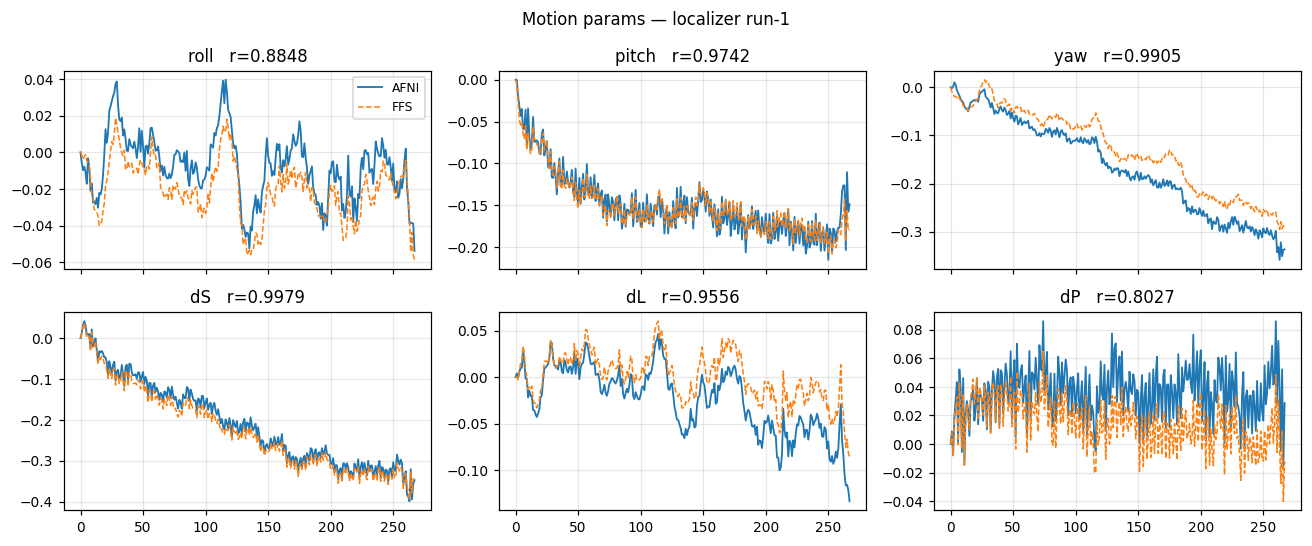

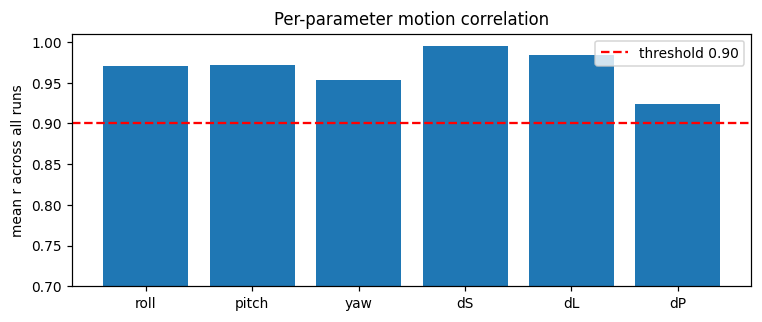

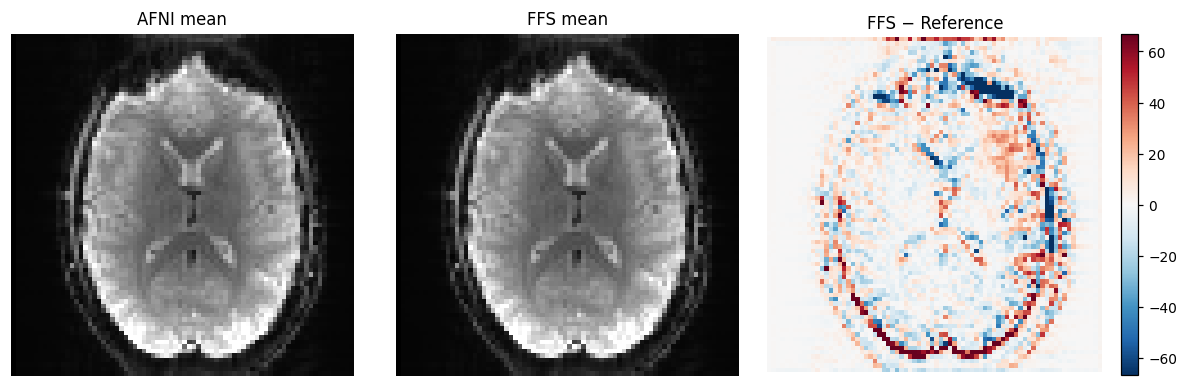

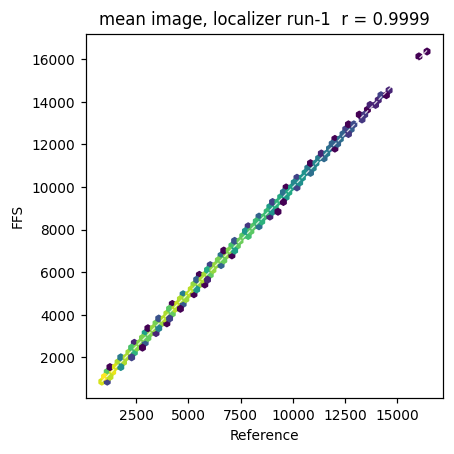

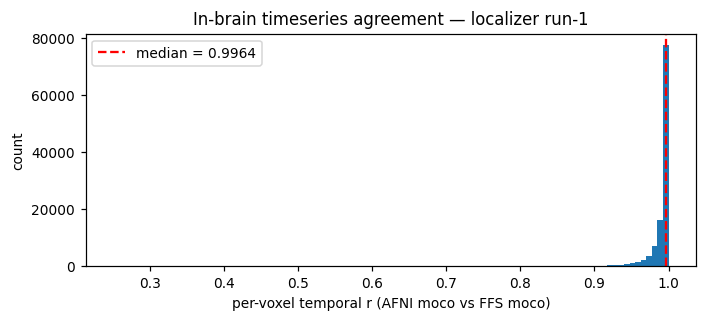

In [233]:
banner('Motion correction (3dvolreg vs ffs_moco)',
       'mean-img r ≥ 0.98, motion r ≥ 0.90, aff12 Δt ≤ 0.5 mm')

MP_NAMES = ['roll', 'pitch', 'yaw', 'dS', 'dL', 'dP']
task, run = PRIMARY_TASK, 1
afni_mp = np.loadtxt(PROC / f'afni_motion_correction_task-{task}_run-{run}.1D')
ffs_mp  = np.loadtxt(PROC / f'ffs_motion_correction_task-{task}_run-{run}.1D')

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(afni_mp[:, i], label='AFNI', lw=1.2)
    ax.plot(ffs_mp[:, i],  label='FFS',  lw=1.0, ls='--')
    r = np.corrcoef(afni_mp[:, i], ffs_mp[:, i])[0, 1]
    ax.set_title(f'{MP_NAMES[i]}   r={r:.4f}'); ax.grid(alpha=0.3)
axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle(f'Motion params — {task} run-{run}'); plt.tight_layout(); plt.show()

# Aggregate per-column r across all (task, run)
all_rs = {n: [] for n in MP_NAMES}
for t, runs in TASKS.items():
    for r in runs:
        a = np.loadtxt(PROC / f'afni_motion_correction_task-{t}_run-{r}.1D')
        f = np.loadtxt(PROC / f'ffs_motion_correction_task-{t}_run-{r}.1D')
        for i, n in enumerate(MP_NAMES):
            all_rs[n].append(np.corrcoef(a[:, i], f[:, i])[0, 1])
fig, ax = plt.subplots(figsize=(7, 3))
means = [np.mean(all_rs[n]) for n in MP_NAMES]
ax.bar(MP_NAMES, means, color='C0'); ax.axhline(0.90, color='red', ls='--', label='threshold 0.90')
ax.set_ylim(0.7, 1.01); ax.set_ylabel('mean r across all runs'); ax.legend()
ax.set_title('Per-parameter motion correlation'); plt.tight_layout(); plt.show()

# Mean-image side-by-side (run 1)
afni_mean, _ = load_vol(PROC / f'afni_mean_{bids(task, run)}_bold.nii')
ffs_mean,  _ = load_vol(PROC / f'ffs_mean_{bids(task, run)}_bold.nii')
show_axial_pair(afni_mean, ffs_mean, 'AFNI mean', 'FFS mean')
mask3d = automask(afni_mean) & automask(ffs_mean)
scatter_voxels(afni_mean, ffs_mean, mask3d, title=f'mean image, {task} run-{run}')

# In-brain voxelwise temporal r between motion-corrected timeseries
afni_4d, _ = load_vol(PROC / f'afni_moco_{bids(task, run)}_bold.nii')
ffs_4d,  _ = load_vol(PROC / f'ffs_moco_{bids(task, run)}_bold.nii')
T = min(afni_4d.shape[-1], ffs_4d.shape[-1])
afni_4d = afni_4d[..., :T]; ffs_4d = ffs_4d[..., :T]
av = afni_4d[mask3d]            # (n_vox, T)
fv = ffs_4d[mask3d]
az = av - av.mean(1, keepdims=True); fz = fv - fv.mean(1, keepdims=True)
denom = az.std(1) * fz.std(1)
ok = denom > 1e-8
rvox = (az[ok] * fz[ok]).mean(1) / denom[ok]
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(rvox, bins=100, color='C0')
ax.axvline(np.median(rvox), color='red', ls='--',
           label=f'median = {np.median(rvox):.4f}')
ax.set(xlabel='per-voxel temporal r (AFNI moco vs FFS moco)', ylabel='count',
       title=f'In-brain timeseries agreement — {task} run-{run}')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Slice-timing correction

**Pass**: voxelwise temporal r — median ≥ 0.99, fraction>0.95 ≥ 0.95.


──────────────────────────────────────────────────────────────────────────────
  Slice-timing (3dTshift vs ffs_tshift)
  PASS criterion: voxelwise temporal r: median ≥ 0.99
──────────────────────────────────────────────────────────────────────────────


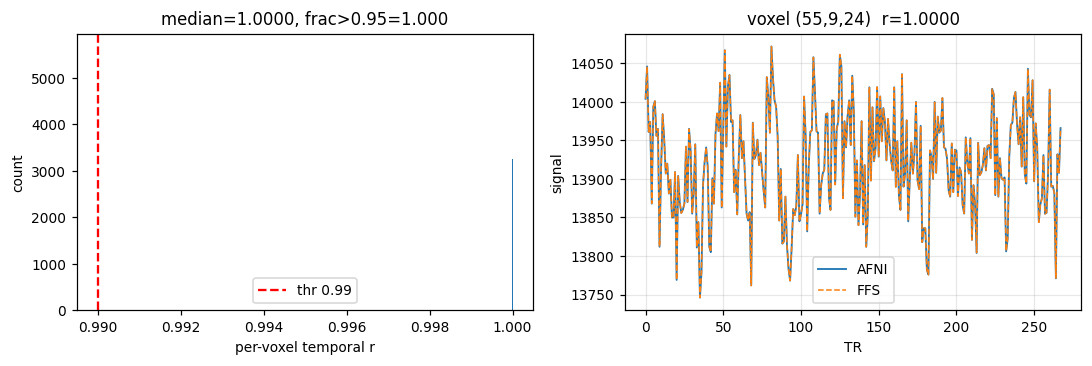

In [234]:
banner('Slice-timing (3dTshift vs ffs_tshift)',
       'voxelwise temporal r: median ≥ 0.99')

# slicetime stage compares afni_tshift_* to ffs_tshift_* directly (same space).
# `ffs_st_resampled_*` is post-resample to a different grid — DO NOT compare it
# against afni_tshift_*.
task, run = PRIMARY_TASK, 1
afni_path = PROC / f'afni_tshift_{bids(task, run)}_bold.nii'
ffs_path  = PROC / f'ffs_tshift_{bids(task, run)}_bold.nii'

a4d, _ = load_vol(afni_path)
f4d, _ = load_vol(ffs_path)
T = min(a4d.shape[-1], f4d.shape[-1])
a4d, f4d = a4d[..., :T], f4d[..., :T]

amean = a4d.mean(-1); fmean = f4d.mean(-1)
mask = automask(amean) & automask(fmean)

# Vectorised per-voxel temporal r over the whole mask
av = a4d[mask]; fv = f4d[mask]   # (n_vox, T)
az = av - av.mean(1, keepdims=True)
fz = fv - fv.mean(1, keepdims=True)
denom = az.std(1) * fz.std(1)
ok = denom > 1e-8
rs = (az[ok] * fz[ok]).mean(1) / denom[ok]
median_r = float(np.median(rs)); frac95 = float((rs > 0.95).mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(rs, bins=80, color='C0'); axes[0].axvline(0.99, color='red', ls='--', label='thr 0.99')
axes[0].set(xlabel='per-voxel temporal r', ylabel='count',
            title=f'median={median_r:.4f}, frac>0.95={frac95:.3f}')
axes[0].legend()
# Sample timecourse from a high-SNR voxel
snr = amean / (a4d.std(-1) + 1e-6)
snr_masked = np.where(mask, snr, 0)
x, y, z = np.unravel_index(np.argmax(snr_masked), snr.shape)
axes[1].plot(a4d[x, y, z], label='AFNI', lw=1.2)
axes[1].plot(f4d[x, y, z], label='FFS',  lw=1.0, ls='--')
axes[1].set(xlabel='TR', ylabel='signal',
            title=f'voxel ({x},{y},{z})  r={np.corrcoef(a4d[x,y,z], f4d[x,y,z])[0,1]:.4f}')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Cross-run alignment

**Pass**: aff12 max Δangle ≤ ~0.5°, Δtrans ≤ 0.5 mm, aligned-image r ≥ 0.98 per pair.


──────────────────────────────────────────────────────────────────────────────
  Cross-run alignment
  PASS criterion: aligned mean-image r ≥ 0.98, aff12 Δrot/Δtrans tiny
──────────────────────────────────────────────────────────────────────────────


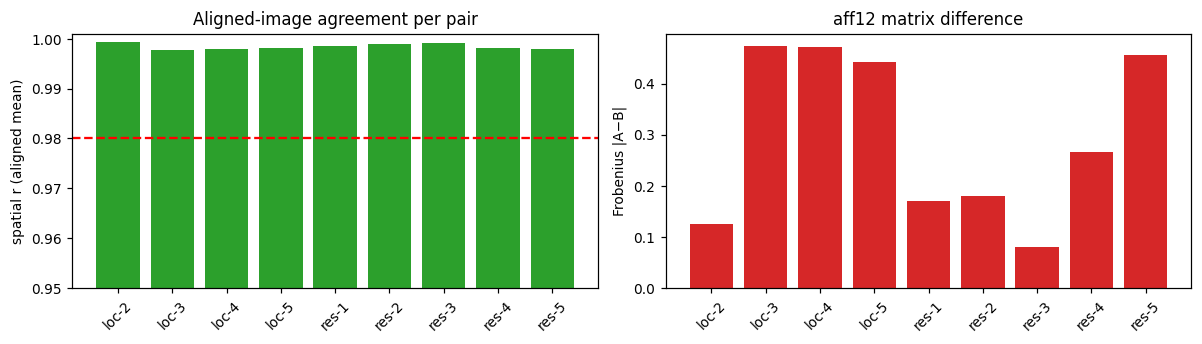

In [235]:
banner('Cross-run alignment',
       'aligned mean-image r ≥ 0.98, aff12 Δrot/Δtrans tiny')

rs, fro = [], []
labels = []
for t, runs in TASKS.items():
    for r in runs:
        if t == PRIMARY_TASK and r == 1: continue
        afni_m = PROC / f'afni_mean_{t}_run-{r}_to_{PRIMARY_TASK}_run-1_mat.aff12.1D'
        ffs_m  = PROC / f'ffs_mean_{t}_run-{r}_to_{PRIMARY_TASK}_run-1_mat.aff12.1D'
        if not (afni_m.exists() and ffs_m.exists()): continue
        a = np.loadtxt(afni_m, comments='#').reshape(-1)
        b = np.loadtxt(ffs_m,  comments='#').reshape(-1)
        fro.append(float(np.linalg.norm(a - b)))
        # aligned image
        afni_img = PROC / f'afni_mean_{bids(t, r)}_bold_al.nii'
        ffs_img  = PROC / f'ffs_mean_{bids(t, r)}_bold_al.nii'
        if afni_img.exists() and ffs_img.exists():
            av, _ = load_vol(afni_img); bv, _ = load_vol(ffs_img)
            m = automask(av) & automask(bv)
            rs.append(spatial_r(av, bv, m))
        labels.append(f'{t[:3]}-{r}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar(labels, rs, color='C2'); axes[0].axhline(0.98, color='red', ls='--')
axes[0].set(ylim=(0.95, 1.001), ylabel='spatial r (aligned mean)',
            title='Aligned-image agreement per pair')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(labels, fro, color='C3')
axes[1].set(ylabel='Frobenius |A−B|', title='aff12 matrix difference')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 4. Anatomical warp to MNI

**Pass**: spatial r ≥ 0.95 between sswarper `anatQQ` and ffs_warper `anatFFS`.


──────────────────────────────────────────────────────────────────────────────
  Anatomical warp (sswarper vs ffs_warper)
  PASS criterion: spatial r ≥ 0.95
──────────────────────────────────────────────────────────────────────────────


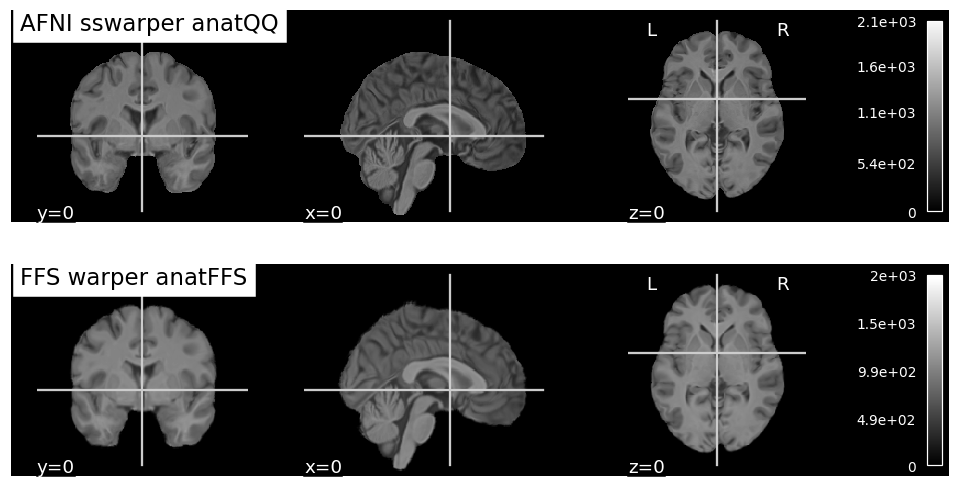

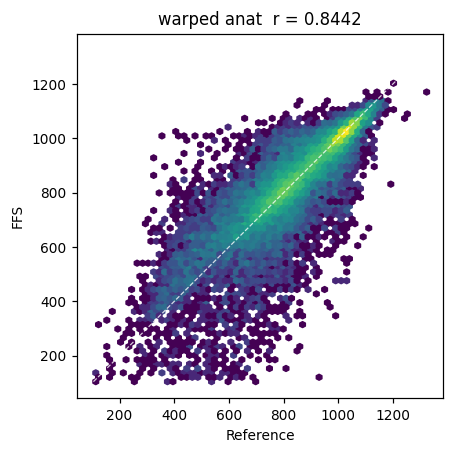

In [236]:
banner('Anatomical warp (sswarper vs ffs_warper)', 'spatial r ≥ 0.95')

afni_anat = PROC / 'sswarper_output' / f'anatQQ.sub-{SUBJECT}.nii'
ffs_anat  = PROC / 'ffs_warper'     / f'anatFFS.sub-{SUBJECT}.nii.gz'

if HAS_NILEARN:
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.5))
    niplot.plot_anat(str(afni_anat), axes=axes[0], title='AFNI sswarper anatQQ',
                     display_mode='ortho', cut_coords=(0, 0, 0))
    niplot.plot_anat(str(ffs_anat), axes=axes[1], title='FFS warper anatFFS',
                     display_mode='ortho', cut_coords=(0, 0, 0))
    plt.show()
else:
    a, _ = load_vol(afni_anat); f, _ = load_vol(ffs_anat)
    show_axial_pair(a, f, 'AFNI anatQQ', 'FFS anatFFS', slice_idx=a.shape[2]//2)

a, _ = load_vol(afni_anat); f, _ = load_vol(ffs_anat)
if a.shape == f.shape:
    m = automask(a) & automask(f)
    scatter_voxels(a, f, m, title='warped anat')

## 5. Functional warp to MNI

**Pass**: voxelwise temporal r — min median ≥ 0.97 across runs.


──────────────────────────────────────────────────────────────────────────────
  Functional warp (afni_mni vs ffs_mni)
  PASS criterion: min median temporal r ≥ 0.97
──────────────────────────────────────────────────────────────────────────────


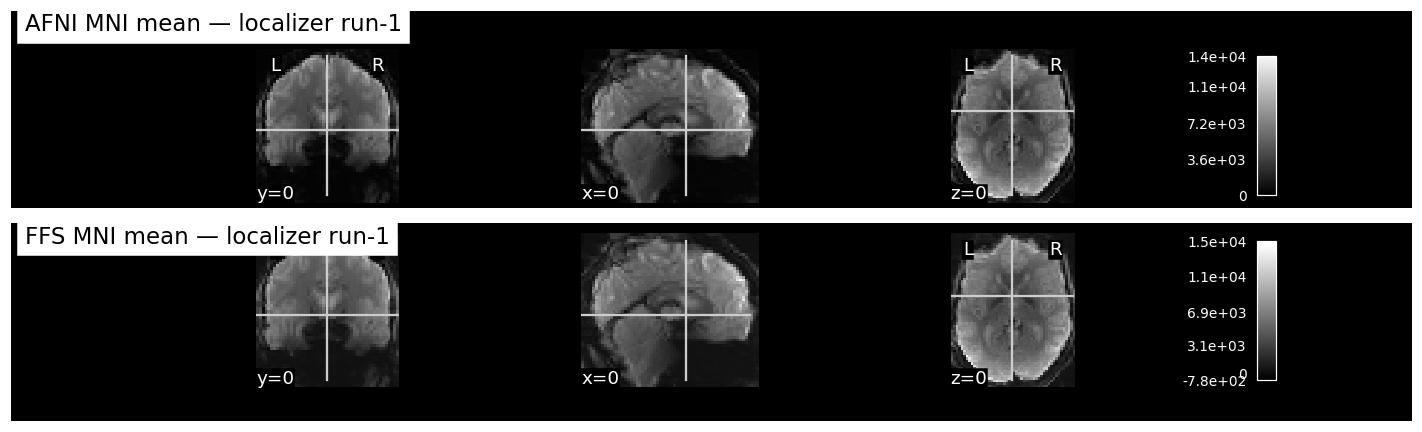

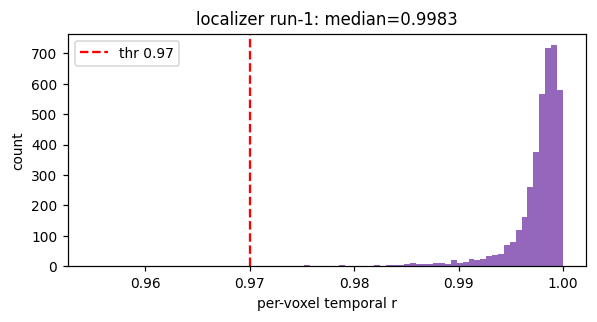

In [237]:
banner('Functional warp (afni_mni vs ffs_mni)', 'min median temporal r ≥ 0.97')

task, run = PRIMARY_TASK, 1
afni_mni = PROC / f'afni_mni_task-{task}_run-{run}.nii.gz'
ffs_mni  = PROC / f'ffs_mni_task-{task}_run-{run}.nii.gz'
a4d, aff_a = load_vol(afni_mni); f4d, aff_f = load_vol(ffs_mni)
T = min(a4d.shape[-1], f4d.shape[-1]); a4d, f4d = a4d[..., :T], f4d[..., :T]

amean = a4d.mean(-1); fmean = f4d.mean(-1)
mask = automask(amean) & automask(fmean)

if HAS_NILEARN:
    fig = plt.figure(figsize=(13, 4))
    ax_a = fig.add_subplot(2, 1, 1)
    ax_b = fig.add_subplot(2, 1, 2)
    niplot.plot_epi(array_to_img(amean, aff_a), axes=ax_a,
                    title=f'AFNI MNI mean — {task} run-{run}',
                    display_mode='ortho', cut_coords=(0, 0, 0))
    niplot.plot_epi(array_to_img(fmean, aff_f), axes=ax_b,
                    title=f'FFS MNI mean — {task} run-{run}',
                    display_mode='ortho', cut_coords=(0, 0, 0))
    plt.tight_layout(); plt.show()
else:
    show_axial_pair(amean, fmean, 'AFNI MNI mean', 'FFS MNI mean')

# per-voxel temporal r
vox = np.argwhere(mask)
sel = vox[np.random.choice(len(vox), min(4000, len(vox)), replace=False)]
rs = []
for x, y, z in sel:
    a, b = a4d[x, y, z], f4d[x, y, z]
    if a.std() > 1e-8 and b.std() > 1e-8:
        rs.append(np.corrcoef(a, b)[0, 1])
rs = np.array(rs)
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.hist(rs, bins=80, color='C4'); ax.axvline(0.97, color='red', ls='--', label='thr 0.97')
ax.set(xlabel='per-voxel temporal r', ylabel='count',
       title=f'{task} run-{run}: median={np.median(rs):.4f}')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Automask

**Pass**: Dice ≥ ~0.95 per run.


──────────────────────────────────────────────────────────────────────────────
  Automask (3dAutomask vs ffs_automask)
  PASS criterion: min Dice ≥ 0.95
──────────────────────────────────────────────────────────────────────────────


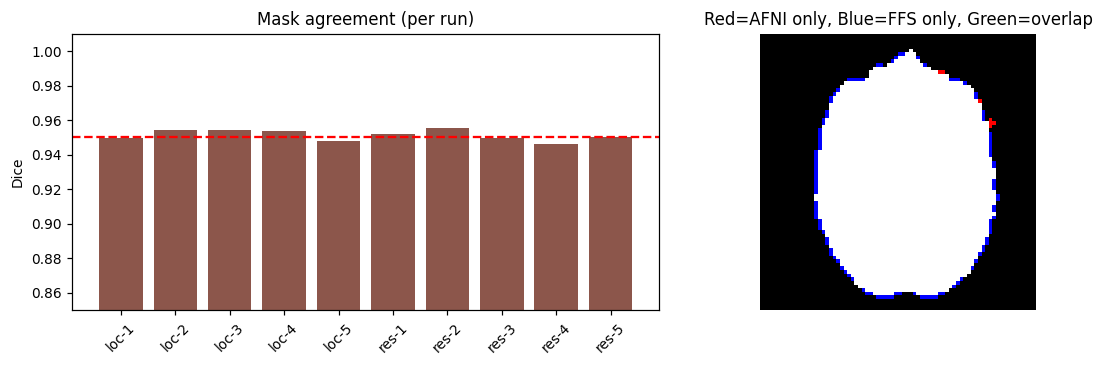

In [238]:
banner('Automask (3dAutomask vs ffs_automask)', 'min Dice ≥ 0.95')

dices = []; labels = []
for t, runs in TASKS.items():
    for r in runs:
        afni_m = PROC / f'automask_afni_mean_{bids(t, r)}_bold.nii'
        ffs_m  = PROC / f'automask_ffs_mean_{bids(t, r)}_bold.nii'
        if not (afni_m.exists() and ffs_m.exists()): continue
        a, _ = load_vol(afni_m); f, _ = load_vol(ffs_m)
        a = a > 0.5; f = f > 0.5
        d = 2 * (a & f).sum() / max((a.sum() + f.sum()), 1)
        dices.append(float(d)); labels.append(f'{t[:3]}-{r}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(labels, dices, color='C5'); axes[0].axhline(0.95, color='red', ls='--')
axes[0].set(ylim=(0.85, 1.01), ylabel='Dice', title='Mask agreement (per run)')
axes[0].tick_params(axis='x', rotation=45)
# Visualise overlap on one run
a, _ = load_vol(PROC / f'automask_afni_mean_{bids(PRIMARY_TASK, 1)}_bold.nii')
f, _ = load_vol(PROC / f'automask_ffs_mean_{bids(PRIMARY_TASK, 1)}_bold.nii')
z = a.shape[2] // 2
overlay = np.zeros((*a.shape[:2], 3))
overlay[..., 0] = (a[..., z] > 0.5)  # red = AFNI
overlay[..., 2] = (f[..., z] > 0.5)  # blue = FFS
overlay[..., 1] = (a[..., z] > 0.5) & (f[..., z] > 0.5)  # green = overlap
axes[1].imshow(overlay.transpose(1, 0, 2), origin='lower')
axes[1].set_title('Red=AFNI only, Blue=FFS only, Green=overlap'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 7. Standard GLM (3dDeconvolve + 3dREMLfit vs ffs_reml)

**Pass**: per-sub-brick spatial r — OLS min ≥ 0.95, REML min ≥ 0.95.


──────────────────────────────────────────────────────────────────────────────
  Standard GLM bucket (per sub-brick spatial r)
  PASS criterion: OLS min_r ≥ 0.95, REML min_r ≥ 0.95
──────────────────────────────────────────────────────────────────────────────


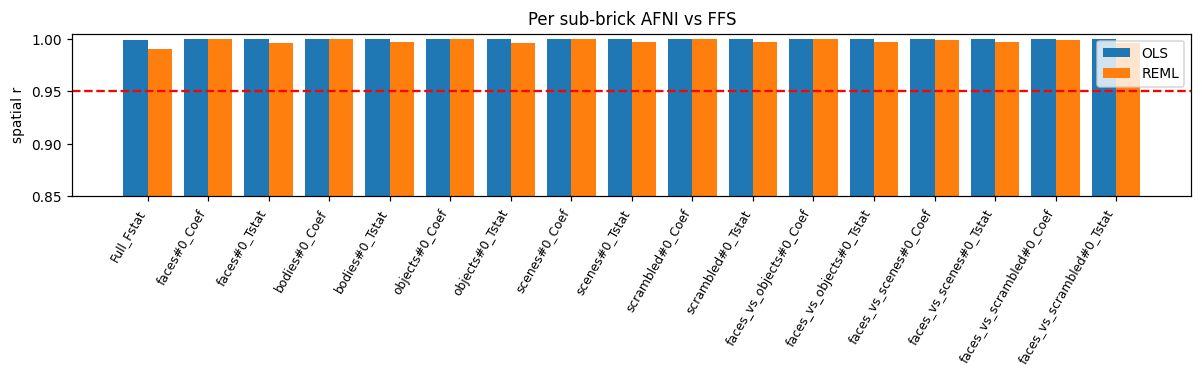

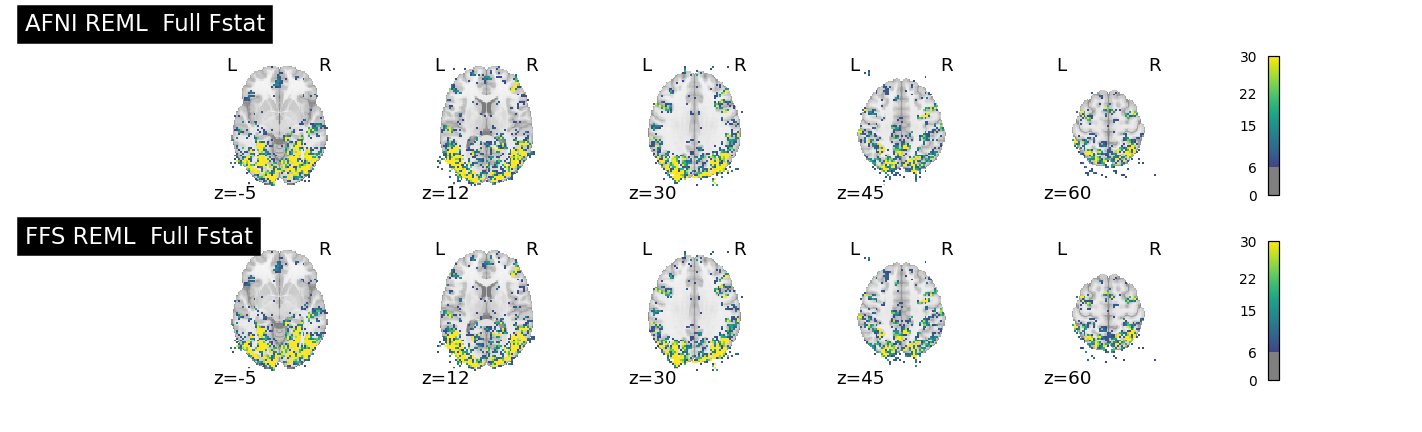

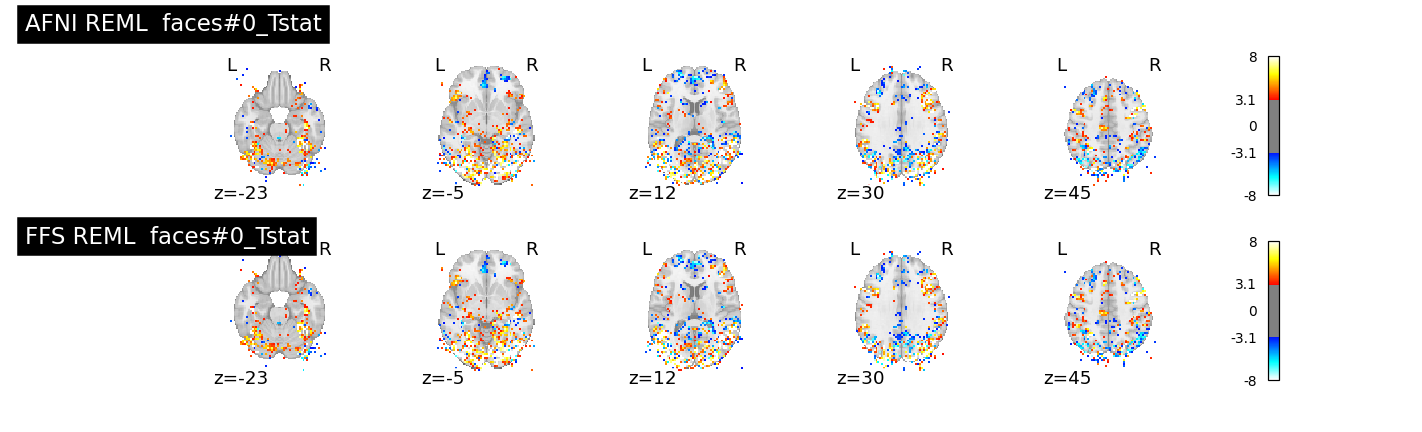

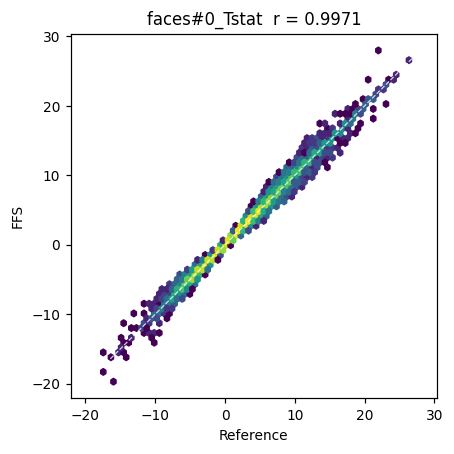

np.float64(0.9970573638218311)

In [239]:
banner('Standard GLM bucket (per sub-brick spatial r)',
       'OLS min_r ≥ 0.95, REML min_r ≥ 0.95')

afni_dir = DATA_ROOT / 'afni_glm'
ffs_dir  = DATA_ROOT / 'ffs_glm'
task = PRIMARY_TASK

afni_ols, _ = load_vol(afni_dir / f'stats_{task}.nii.gz')
ffs_ols,  _ = load_vol(ffs_dir  / f'stats_{task}.nii.gz')
afni_reml, aff_reml = load_vol(afni_dir / f'stats_{task}_REML+tlrc.HEAD')
ffs_reml,  aff_ffs  = load_vol(ffs_dir  / f'stats_{task}_REML.nii.gz')
labels = (ffs_dir / f'stats_{task}_REML_labels.txt').read_text().split()

def per_brick_r(a, b):
    n = min(a.shape[-1], b.shape[-1])
    m = automask(a[..., 0])
    return [spatial_r(a[..., i], b[..., i], m) for i in range(n)]

ols_rs  = per_brick_r(afni_ols, ffs_ols)
reml_rs = per_brick_r(afni_reml, ffs_reml)

fig, ax = plt.subplots(figsize=(11, 3.5))
x = np.arange(len(reml_rs))
w = 0.4
ax.bar(x - w/2, ols_rs[:len(reml_rs)],  w, label='OLS',  color='C0')
ax.bar(x + w/2, reml_rs, w, label='REML', color='C1')
ax.axhline(0.95, color='red', ls='--')
ax.set_xticks(x); ax.set_xticklabels(labels[:len(reml_rs)], rotation=60, ha='right', fontsize=8)
ax.set(ylim=(0.85, 1.005), ylabel='spatial r', title='Per sub-brick AFNI vs FFS')
ax.legend(); plt.tight_layout(); plt.show()

# Pretty MNI for F-stat to make sure it works
tstat_idx = next(i for i, lb in enumerate(labels) if 'faces#0_Tstat' in lb)
img_a = array_to_img(afni_reml[..., 0], aff_reml)
img_f = array_to_img(ffs_reml[..., 0], aff_ffs)
pretty_stat_pair(img_a, img_f,
                 f'AFNI REML  Full Fstat', f'FFS REML  Full Fstat',
                 threshold=6, vmax=30, display_mode='z', cmap = 'viridis',
                 cut_coords=5 if HAS_NILEARN else None)

# Pretty MNI t-stat overlay for faces#0_Tstat
tstat_idx = next(i for i, lb in enumerate(labels) if 'faces#0_Tstat' in lb)
img_a = array_to_img(afni_reml[..., tstat_idx], aff_reml)
img_f = array_to_img(ffs_reml[..., tstat_idx], aff_ffs)
pretty_stat_pair(img_a, img_f,
                 f'AFNI REML  {labels[tstat_idx]}', f'FFS REML  {labels[tstat_idx]}',
                 threshold=3.1, vmax=8, display_mode='z',
                 cut_coords=5 if HAS_NILEARN else None)

scatter_voxels(afni_reml[..., tstat_idx], ffs_reml[..., tstat_idx],
               automask(afni_ols[..., 0]), title=labels[tstat_idx])

## 8. GLM IM (single-trial OLS + REML)

Bucket layout: vol 0 = F-stat, then alternating (β, t-stat, β, t-stat, …) per trial.

**Pass**: F-stat r ≥ 0.95, β min_r ≥ 0.95, β temporal-median r ≥ 0.85, same for t-stats.


──────────────────────────────────────────────────────────────────────────────
  GLM IM single-trial (OLS)
  PASS criterion: F r ≥ 0.95, β/t min spatial r ≥ 0.95, β/t temporal median r ≥ 0.85
──────────────────────────────────────────────────────────────────────────────
F-stat spatial r           : 0.5136
β   per-trial spatial r    : min=0.7787  mean=0.9904  (600 trials)
β   voxelwise temporal r   : median=0.9983
t   per-trial spatial r    : min=0.8908  mean=0.9919


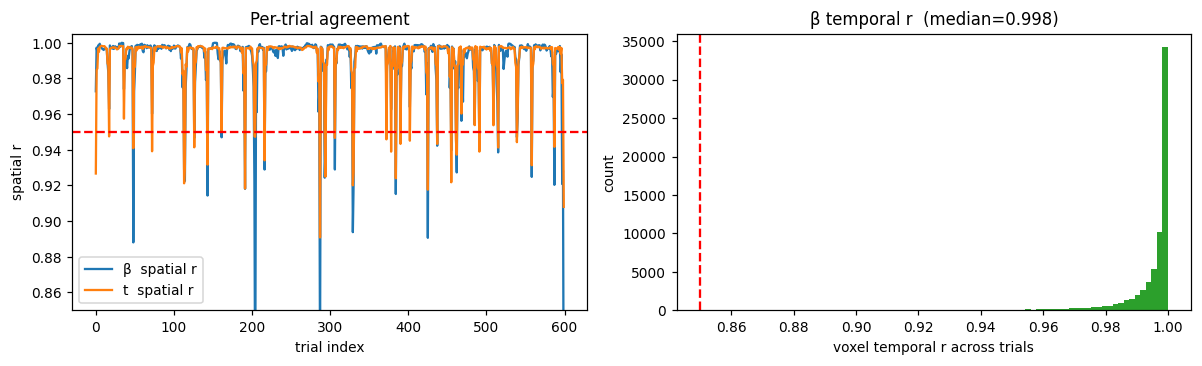

Max β spatial r: 1.0000 at trial index 305


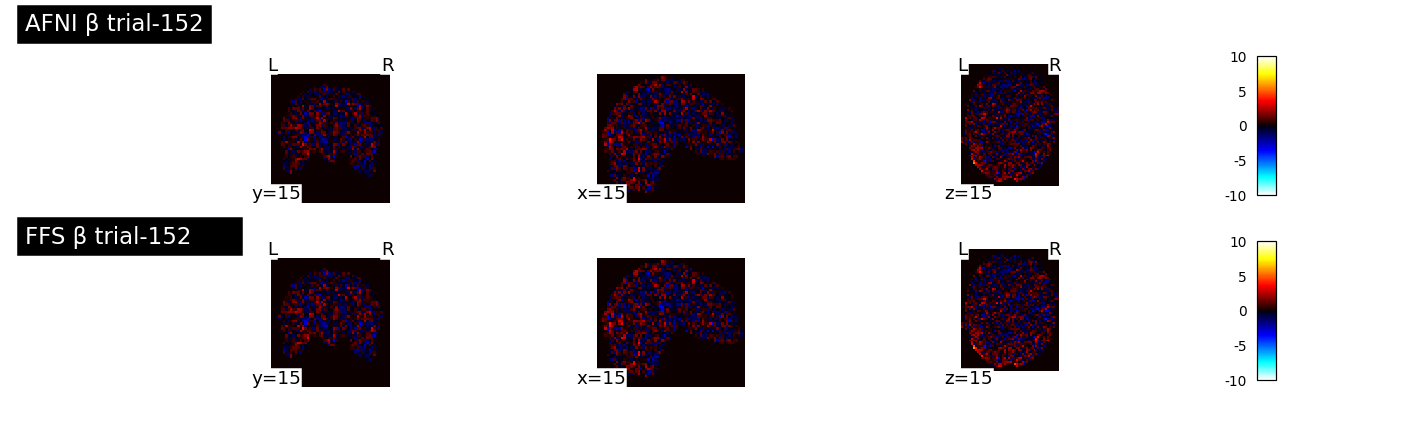

Min β spatial r: 0.7787 at trial index 1199


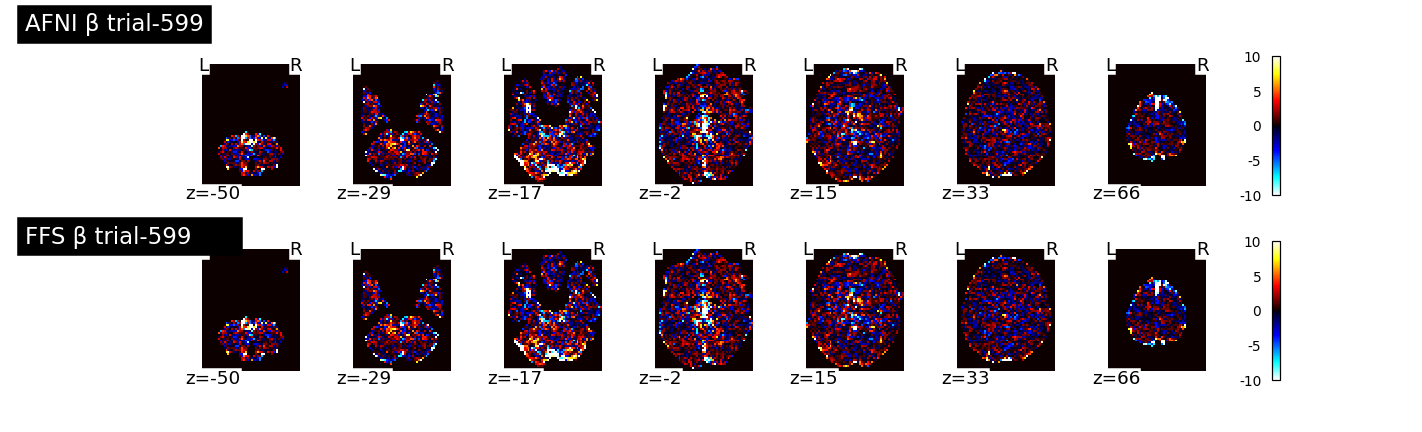

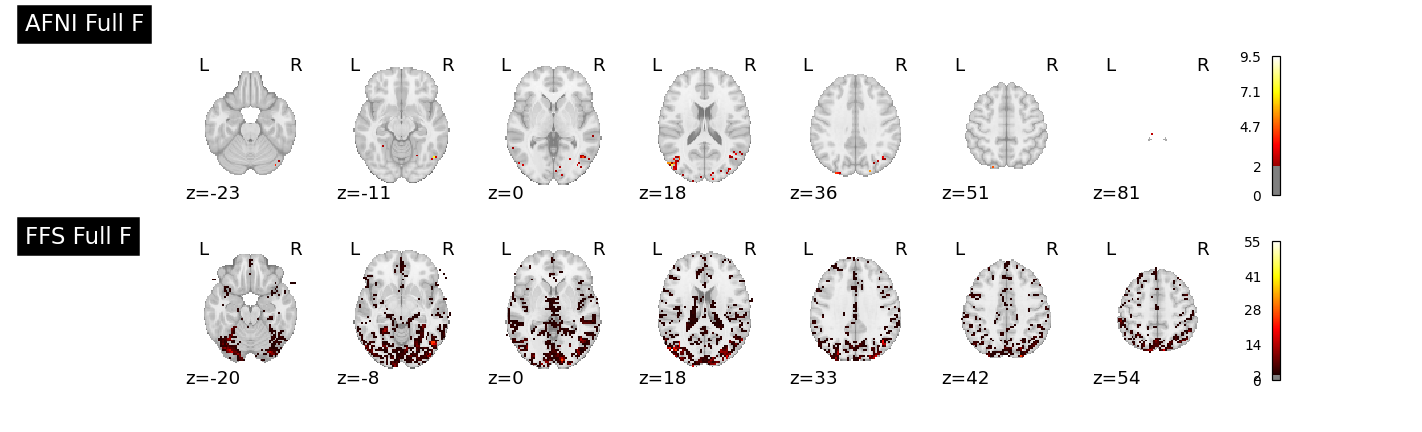

Min β spatial r: 0.7787 at trial index 1199


In [240]:
banner('GLM IM single-trial (OLS)',
       'F r ≥ 0.95, β/t min spatial r ≥ 0.95, β/t temporal median r ≥ 0.85')

afni_im_p = DATA_ROOT / 'afni_glm_IM' / f'IM_afni_stats_{PRIMARY_TASK}_REML+tlrc.HEAD'
ffs_im_p  = DATA_ROOT / 'ffs_glm_IM'  / f'IM_ffs_stats_{PRIMARY_TASK}.nii.gz'
afni_im, aff_a = load_vol(afni_im_p)
ffs_im,  aff_f = load_vol(ffs_im_p)
n = min(afni_im.shape[-1], ffs_im.shape[-1])
afni_im, ffs_im = afni_im[..., :n], ffs_im[..., :n]

mask = automask(afni_im[..., 0])
beta_idx  = list(range(1, n, 2))
tstat_idx = list(range(2, n, 2))

fstat_r  = spatial_r(afni_im[..., 0], ffs_im[..., 0], mask)
beta_rs  = [spatial_r(afni_im[..., i], ffs_im[..., i], mask) for i in beta_idx]
tstat_rs = [spatial_r(afni_im[..., i], ffs_im[..., i], mask) for i in tstat_idx]

# voxelwise temporal r across trials (β only)
a_betas = afni_im[..., beta_idx][mask]
f_betas = ffs_im[..., beta_idx][mask]
az = a_betas - a_betas.mean(1, keepdims=True)
bz = f_betas - f_betas.mean(1, keepdims=True)
denom = az.std(1) * bz.std(1)
valid = denom > 1e-8
vox_r = np.zeros(len(a_betas))
vox_r[valid] = (az[valid] * bz[valid]).mean(1) / denom[valid]
beta_temp_med = float(np.median(vox_r[valid]))

print(f'F-stat spatial r           : {fstat_r:.4f}')
print(f'β   per-trial spatial r    : min={min(beta_rs):.4f}  mean={np.mean(beta_rs):.4f}  ({len(beta_rs)} trials)')
print(f'β   voxelwise temporal r   : median={beta_temp_med:.4f}')
print(f't   per-trial spatial r    : min={min(tstat_rs):.4f}  mean={np.mean(tstat_rs):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(beta_rs,  label='β  spatial r',  color='C0')
axes[0].plot(tstat_rs, label='t  spatial r',  color='C1')
axes[0].axhline(0.95, color='red', ls='--')
axes[0].set(xlabel='trial index', ylabel='spatial r',
            title='Per-trial agreement', ylim=(0.85, 1.005)); axes[0].legend()
axes[1].hist(vox_r[valid], bins=80, color='C2')
axes[1].axvline(0.85, color='red', ls='--')
axes[1].set(xlabel='voxel temporal r across trials', ylabel='count',
            title=f'β temporal r  (median={beta_temp_med:.3f})')
plt.tight_layout(); plt.show()

# Lets find the max and min of the beta_rs so we can look at those. 
max_idx = np.argmax(beta_rs)
min_idx = np.argmin(beta_rs)
print(f'Max β spatial r: {beta_rs[max_idx]:.4f} at trial index {beta_idx[max_idx]}')
# Pretty MNI overlay of trial-1 β and the F-stat
max_img_a_b1 = array_to_img(afni_im[..., max_idx], aff_a)
max_img_f_b1 = array_to_img(ffs_im[..., max_idx],  aff_f)
pretty_stat_pair(max_img_a_b1, max_img_f_b1, f'AFNI β trial-{max_idx}', f'FFS β trial-{max_idx}      ',
                 threshold=None, cmap='cold_hot', display_mode='ortho', vmax=10,
                 cut_coords=(15,15,15) if HAS_NILEARN else None)

print(f'Min β spatial r: {beta_rs[min_idx]:.4f} at trial index {beta_idx[min_idx]}')
# Pretty MNI overlay of trial-1 β and the F-stat
min_img_a_b1 = array_to_img(afni_im[..., min_idx], aff_a)
min_img_f_b1 = array_to_img(ffs_im[..., min_idx],  aff_f)
pretty_stat_pair(min_img_a_b1, min_img_f_b1, f'AFNI β trial-{min_idx}', f'FFS β trial-{min_idx}      ',
                 threshold=None, cmap='cold_hot', display_mode='z', vmax=10,
                 cut_coords=7 if HAS_NILEARN else None)

img_a_F = array_to_img(afni_im[..., 0], aff_a)
img_f_F = array_to_img(ffs_im[..., 0],  aff_f)
pretty_stat_pair(img_a_F, img_f_F, 'AFNI Full F', 'FFS Full F',
                 threshold=2.0, cmap='hot', display_mode='z',
                 cut_coords=7 if HAS_NILEARN else None)
print(f'Min β spatial r: {beta_rs[min_idx]:.4f} at trial index {beta_idx[min_idx]}')


## 9. GLM TENT (FIR HRF estimation)

**Pass per condition**: voxelwise temporal r across the 11 TENT bases — median ≥ 0.85;
spatial r at middle timepoint ≥ 0.90.


──────────────────────────────────────────────────────────────────────────────
  TENT FIR (3dDeconvolve TENT vs ffs_deconvolve)
  PASS criterion: temporal median r ≥ 0.85 per condition
──────────────────────────────────────────────────────────────────────────────


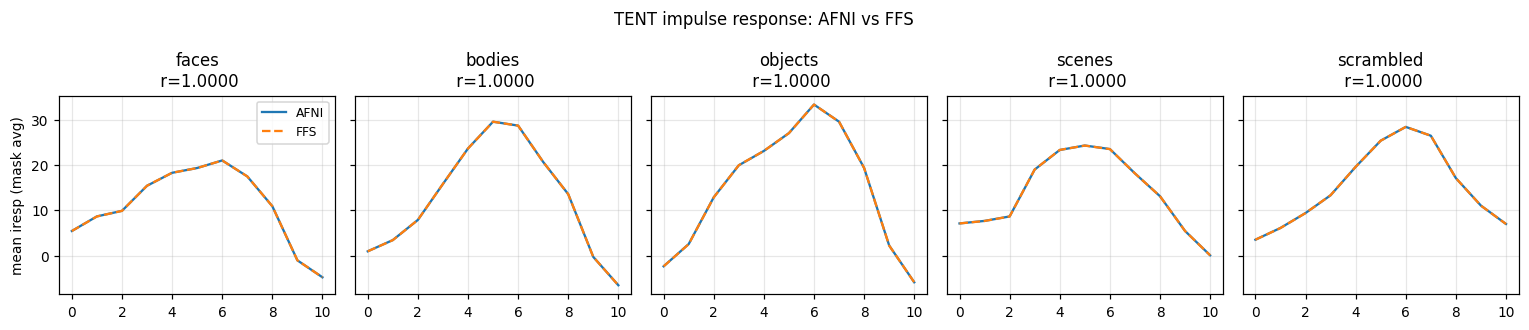

Showing peak TENT basis t=6 for 'faces'


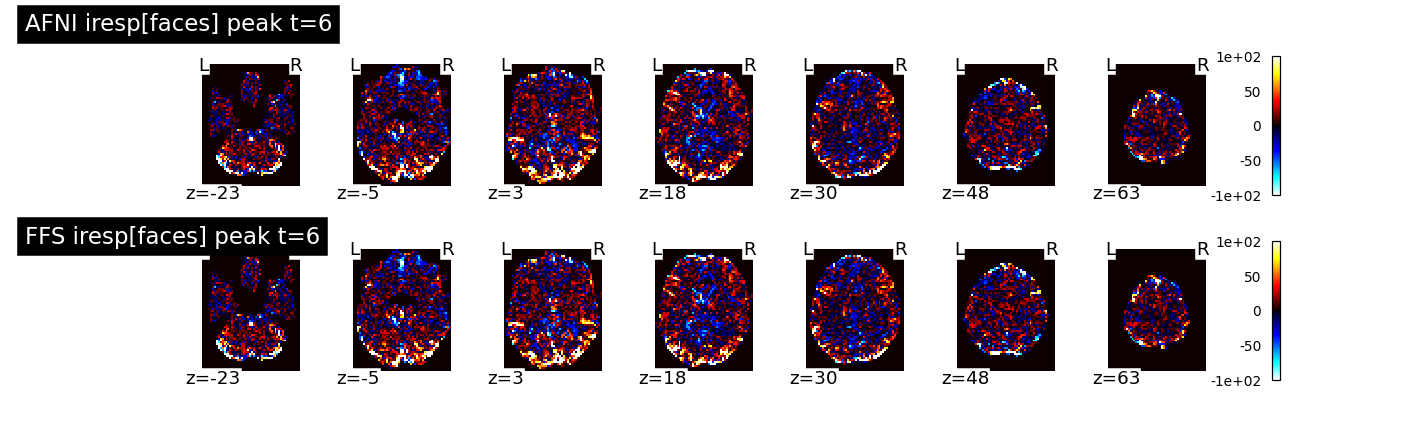

In [241]:
banner('TENT FIR (3dDeconvolve TENT vs ffs_deconvolve)',
       'temporal median r ≥ 0.85 per condition')

# Per-condition mean iresp curves (averaged over a brain mask)
fig, axes = plt.subplots(1, len(STIM_LABELS), figsize=(14, 3), sharey=True)
for ax, label in zip(axes, STIM_LABELS):
    afni_p = DATA_ROOT / 'afni_glm_TENT' / f'iresp_{label}+tlrc.HEAD'
    ffs_p  = DATA_ROOT / 'ffs_glm_TENT'  / f'ffs_tent_iresp_{label}.nii.gz'
    a, _ = load_vol(afni_p); f, _ = load_vol(ffs_p)
    a, f = np.squeeze(a), np.squeeze(f)
    nb = min(a.shape[-1], f.shape[-1])
    a, f = a[..., :nb], f[..., :nb]
    m = automask(a.mean(-1)) & automask(f.mean(-1))
    a_avg = a[m].mean(0); f_avg = f[m].mean(0)
    ax.plot(a_avg, label='AFNI', lw=1.5)
    ax.plot(f_avg, label='FFS', ls='--')
    r = np.corrcoef(a_avg, f_avg)[0, 1]
    ax.set_title(f'{label}\n r={r:.4f}'); ax.grid(alpha=0.3)
axes[0].set_ylabel('mean iresp (mask avg)'); axes[0].legend(fontsize=8)
fig.suptitle('TENT impulse response: AFNI vs FFS'); plt.tight_layout(); plt.show()

# Pretty MNI overlay of peak TENT response for 'faces'
label = 'faces'
a_arr, aff_a = load_vol(DATA_ROOT / 'afni_glm_TENT' / f'iresp_{label}+tlrc.HEAD')
f_arr, aff_f = load_vol(DATA_ROOT / 'ffs_glm_TENT' / f'ffs_tent_iresp_{label}.nii.gz')
a_arr, f_arr = np.squeeze(a_arr), np.squeeze(f_arr)
nb = min(a_arr.shape[-1], f_arr.shape[-1])
# Pick the peak timepoint (per-mask average peak)
m = automask(a_arr.mean(-1))
peak_t = int(np.argmax(a_arr[m].mean(0)))
img_a = array_to_img(a_arr[..., peak_t], aff_a)
img_f = array_to_img(f_arr[..., peak_t], aff_f)
print(f"Showing peak TENT basis t={peak_t} for '{label}'")
pretty_stat_pair(img_a, img_f,
                 f'AFNI iresp[{label}] peak t={peak_t}',
                 f'FFS iresp[{label}] peak t={peak_t}',
                 threshold=None, vmax=100, display_mode='z',
                 cut_coords=7 if HAS_NILEARN else None)

## 10. ICA (MELODIC vs ffs_ica)

**Pass**: optimal-matched mean |r| ≥ 0.85, coverage@0.5 ≥ 0.80.

ICA components are sign- and order-ambiguous, so we use **absolute correlation +
Hungarian matching** (same as `compare_ica_components`).


──────────────────────────────────────────────────────────────────────────────
  ICA concat (MELODIC vs ffs_ica)
  PASS criterion: mean matched |r| ≥ 0.85, coverage@0.5 ≥ 0.80
──────────────────────────────────────────────────────────────────────────────
 localizer: melodic=148 ffs=147  mean |r|=0.796  cov@0.5=0.88


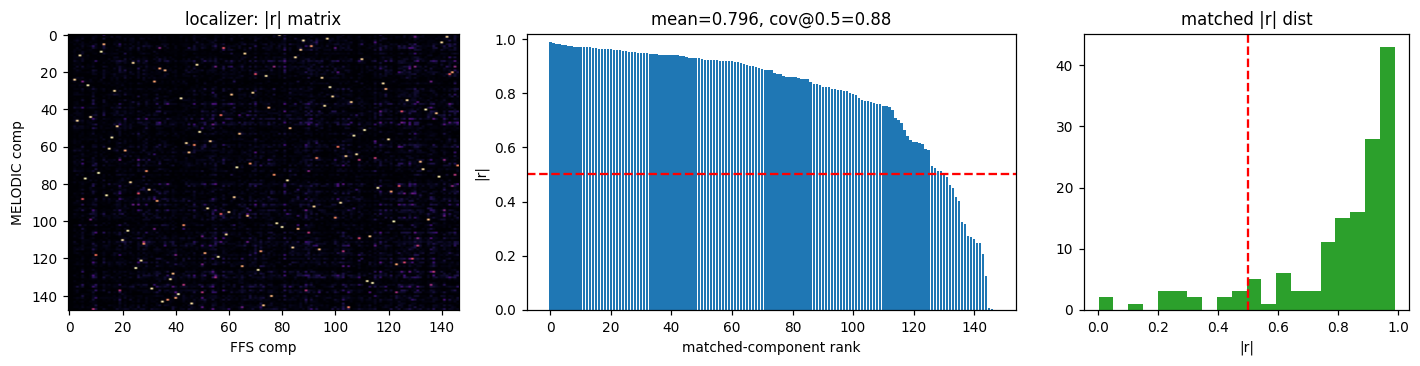

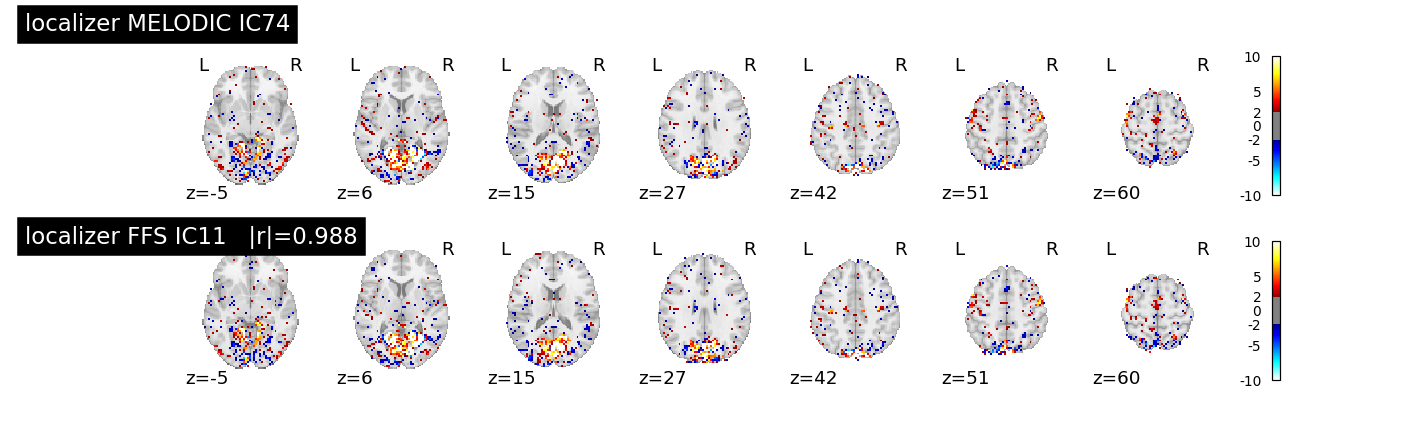

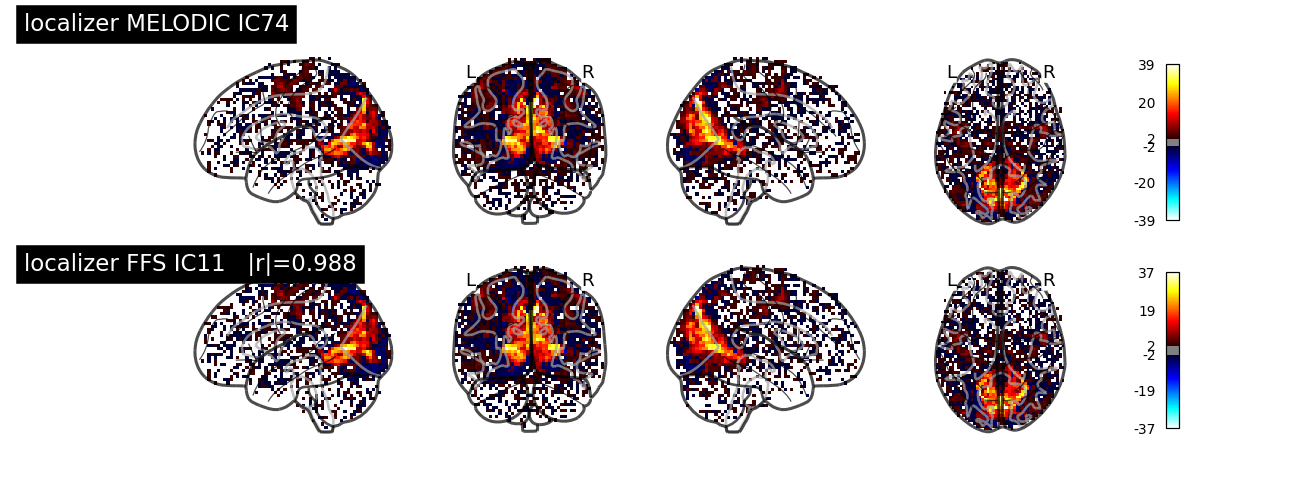

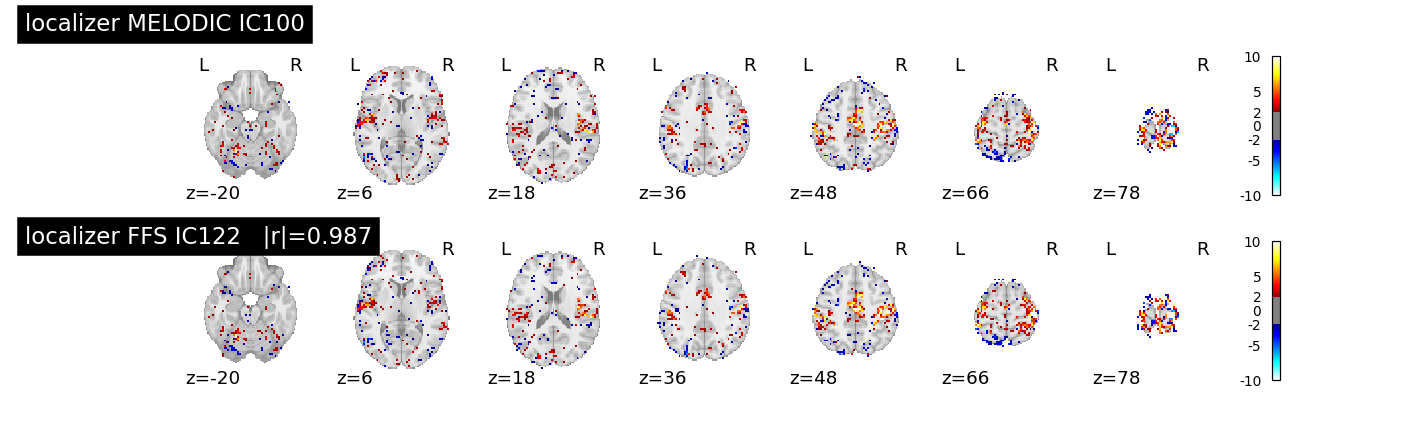

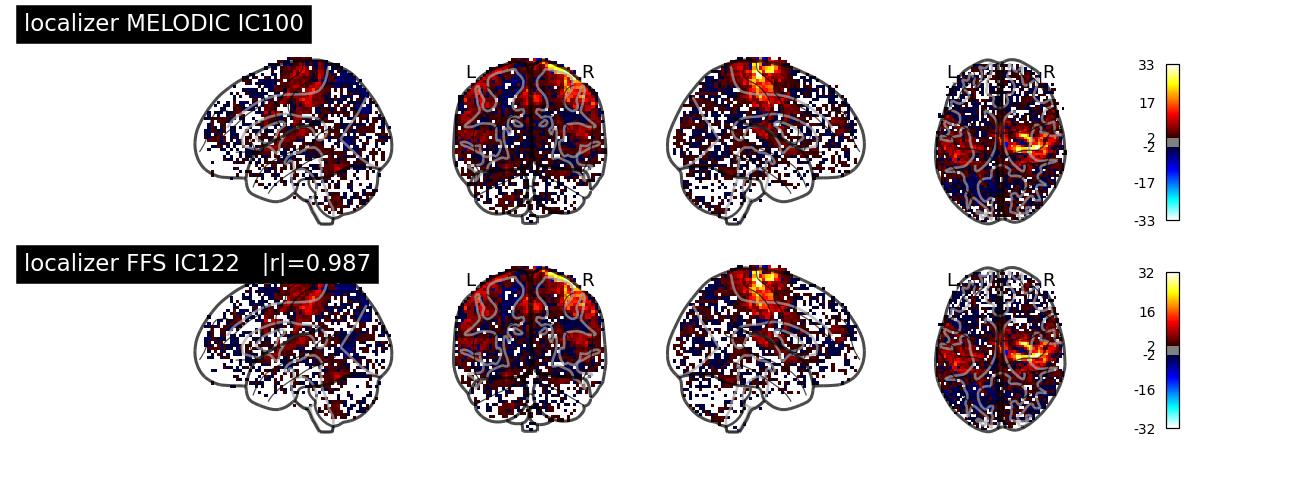

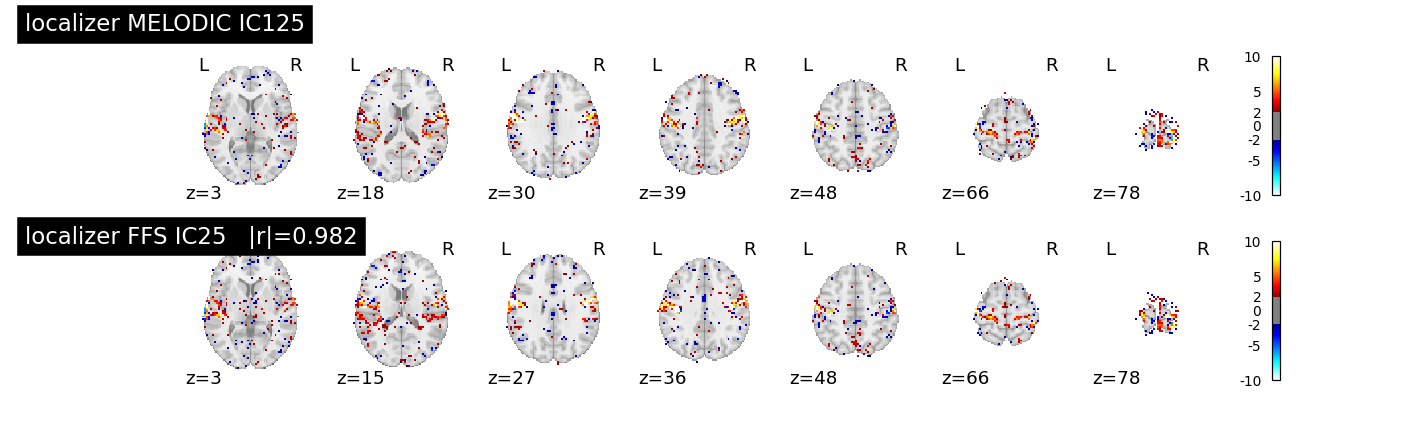

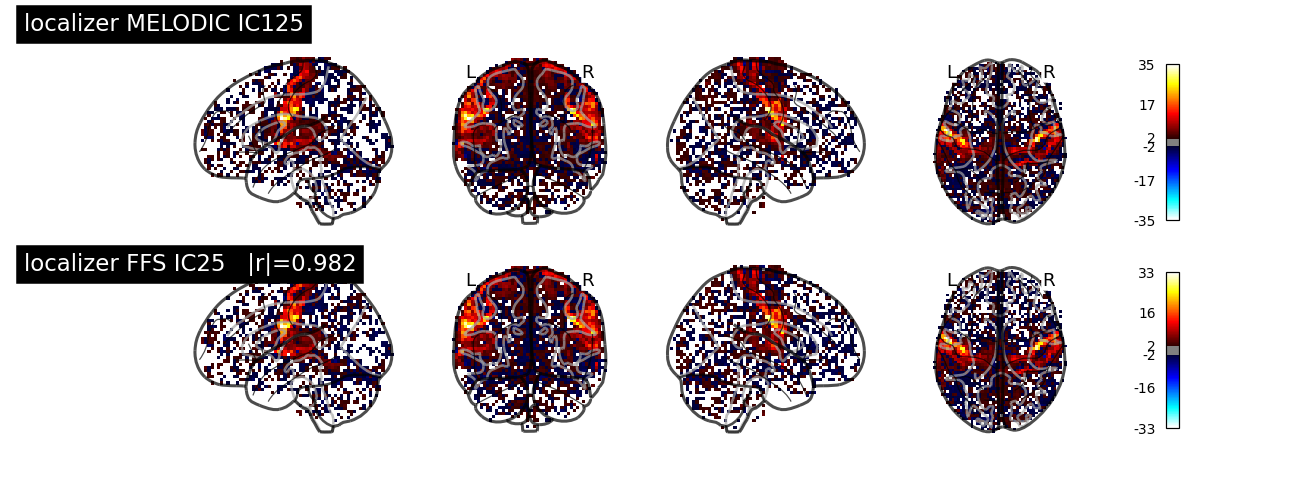

      rest: melodic=147 ffs=147  mean |r|=0.770  cov@0.5=0.83


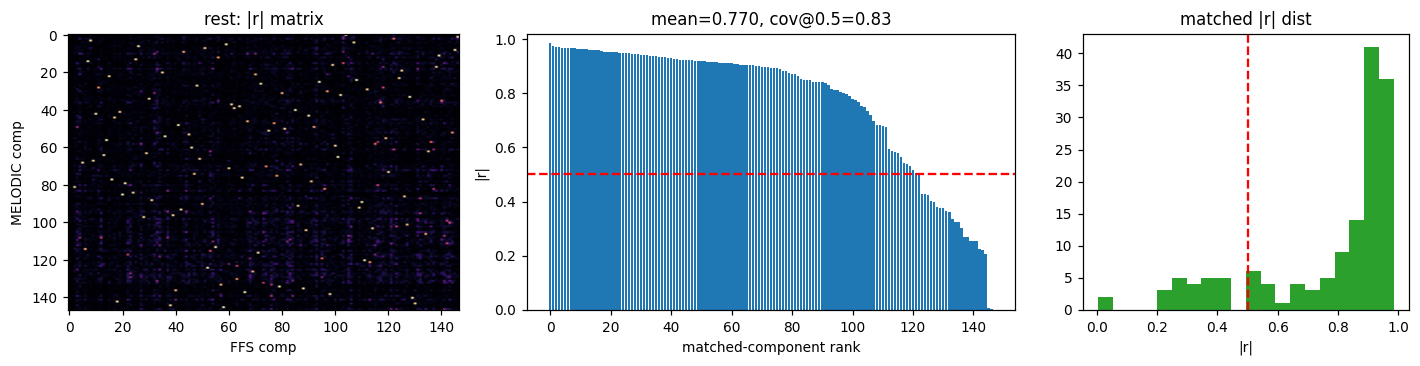

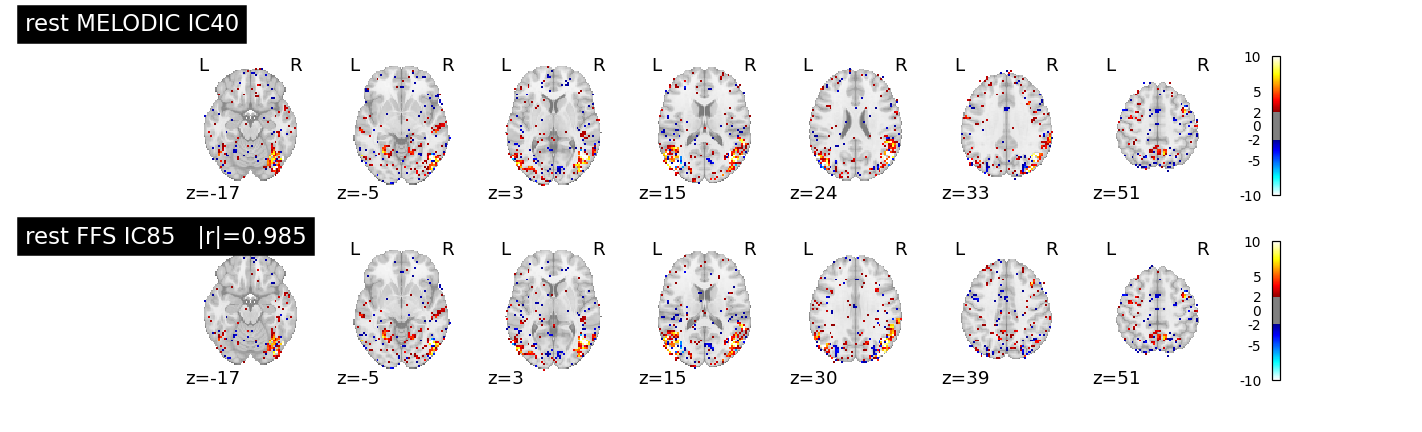

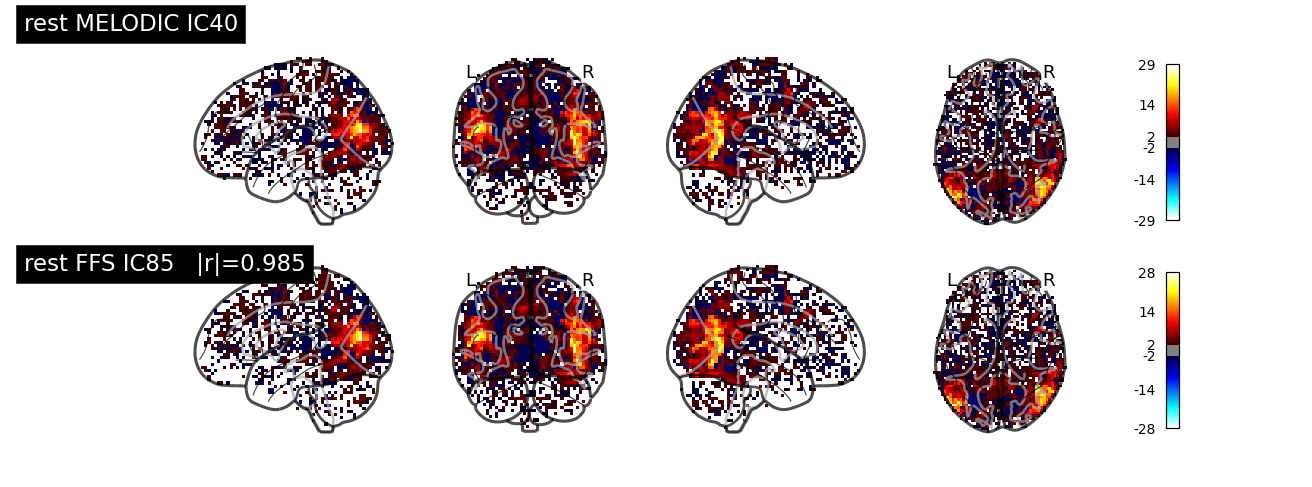

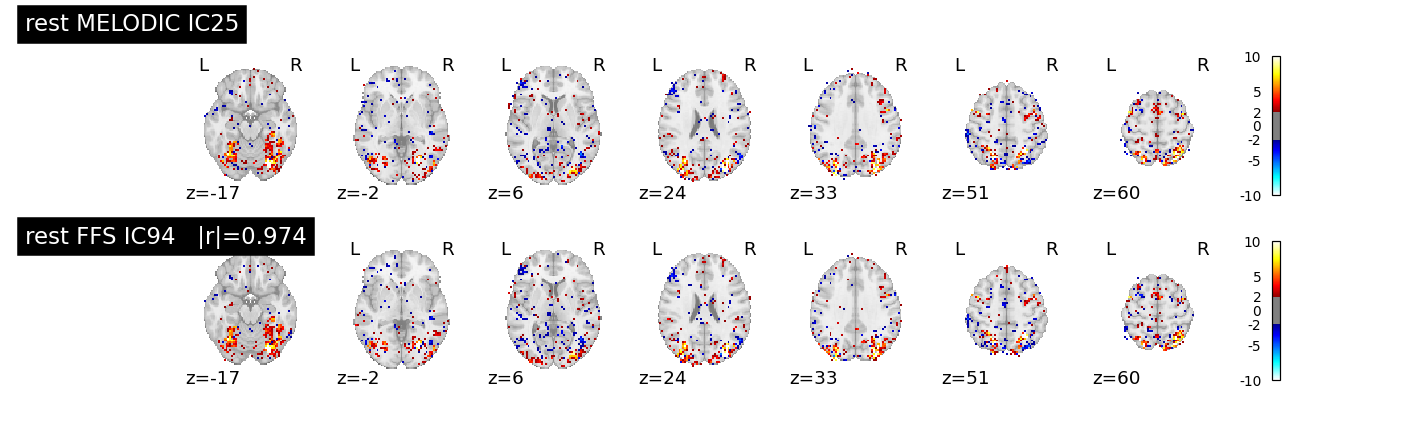

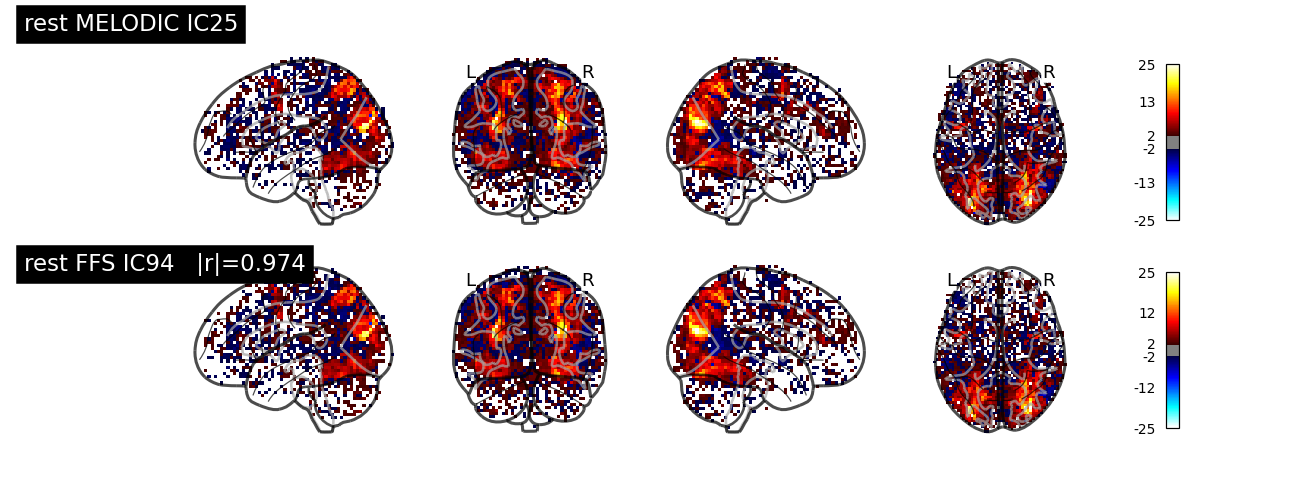

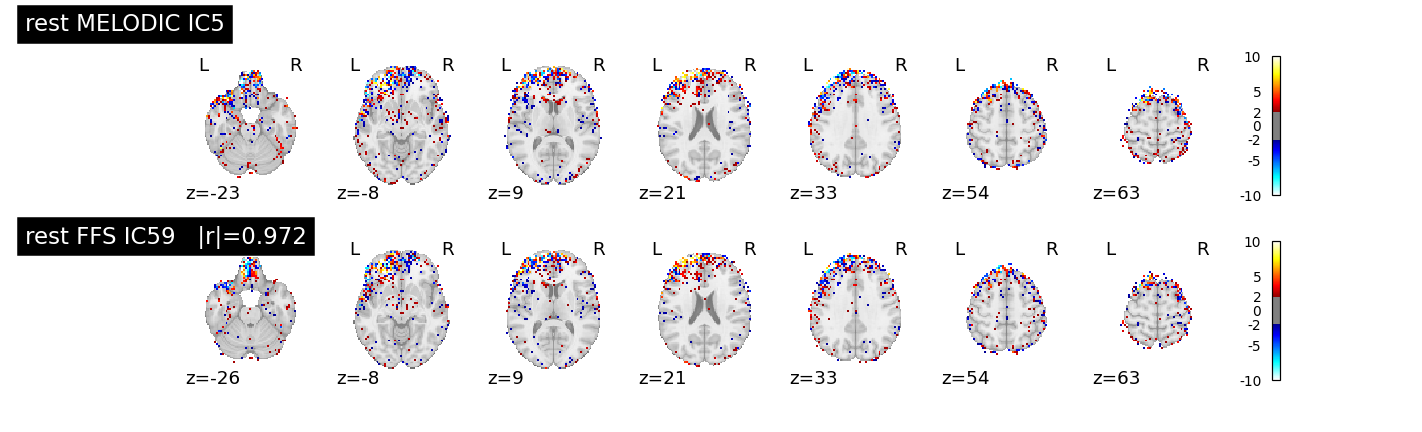

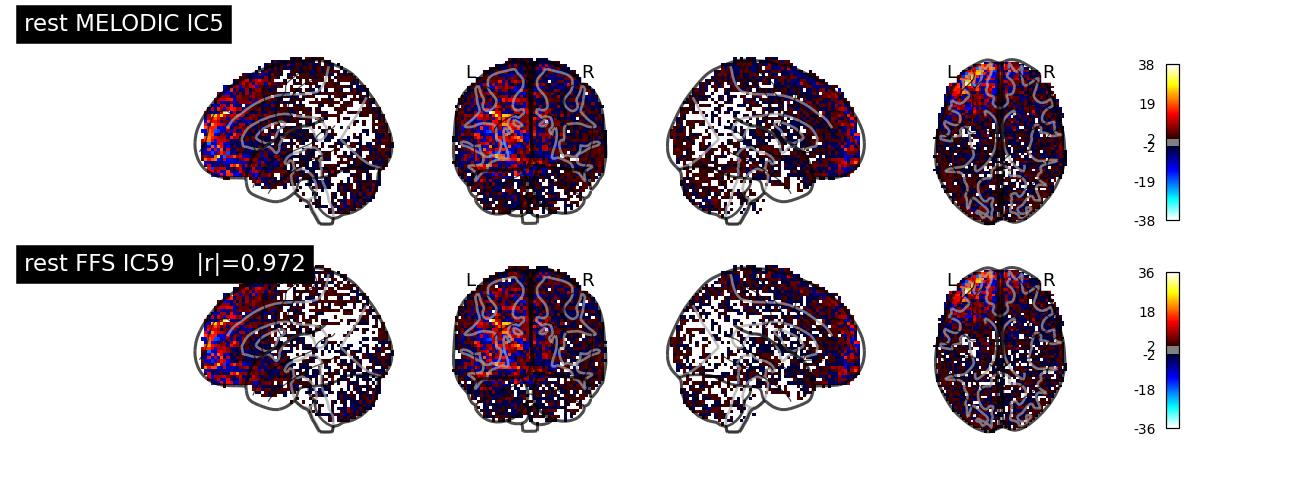

In [242]:
# TODO - add an example for the single run cases in another cell, I think they look even better?

banner('ICA concat (MELODIC vs ffs_ica)',
       'mean matched |r| ≥ 0.85, coverage@0.5 ≥ 0.80')

from scipy.optimize import linear_sum_assignment

def load_components(path):
    arr, aff = load_vol(path)
    if arr.ndim == 3: arr = arr[..., None]
    return arr.transpose(3, 0, 1, 2), aff   # (n_comp, x, y, z), affine

def match_components(a, b, mask):
    A = a.reshape(a.shape[0], -1)[:, mask.ravel()].astype(np.float64)
    B = b.reshape(b.shape[0], -1)[:, mask.ravel()].astype(np.float64)
    A -= A.mean(1, keepdims=True); B -= B.mean(1, keepdims=True)
    A /= (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B /= (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    C = A @ B.T            # signed
    Cabs = np.abs(C)
    ri, ci = linear_sum_assignment(-Cabs)
    return ri, ci, Cabs[ri, ci], np.sign(C[ri, ci]), Cabs
# localizer_single_trace_run01_run01_ica_maps.nii.gz 
# all_localizer_trace_concat_concat_ica_maps.nii.gz
for dataset in ['localizer', 'rest']: 
    melodic_p = DATA_ROOT / 'melodic_ica' / f'all_{dataset}_melodic.ica' / 'melodic_IC.nii.gz'
    ffs_p     = DATA_ROOT / 'ffs_ica'     / f'all_{dataset}_concat_concat.ica' / 'melodic_IC.nii.gz'
    mask_p    = DATA_ROOT / 'melodic_ica' / f'all_{dataset}_melodic.ica' / 'mask.nii.gz'
    if not all(p.exists() for p in [melodic_p, ffs_p, mask_p]):
        print(f'  ({dataset}) missing files; skipping'); continue

    a, aff_a = load_components(melodic_p)
    b, aff_b = load_components(ffs_p)
    mvol, _ = load_vol(mask_p); mask = mvol > 0.5
    ri, ci, matched, signs, C = match_components(a, b, mask)
    mean_r = matched.mean(); cov = (matched >= 0.5).mean()
    print(f'{dataset:>10s}: melodic={a.shape[0]} ffs={b.shape[0]}  '
          f'mean |r|={mean_r:.3f}  cov@0.5={cov:.2f}')

    # Summary panel
    fig = plt.figure(figsize=(13, 3.4))
    gs0 = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.5, 1])
    ax0 = fig.add_subplot(gs0[0])
    ax0.imshow(C, aspect='auto', cmap='magma', vmin=0, vmax=1)
    ax0.set(xlabel='FFS comp', ylabel='MELODIC comp', title=f'{dataset}: |r| matrix')
    ax1 = fig.add_subplot(gs0[1])
    ax1.bar(np.arange(len(matched)), sorted(matched, reverse=True), color='C0')
    ax1.axhline(0.5, color='red', ls='--')
    ax1.set(xlabel='matched-component rank', ylabel='|r|',
            title=f'mean={mean_r:.3f}, cov@0.5={cov:.2f}', ylim=(0, 1.02))
    ax2 = fig.add_subplot(gs0[2])
    ax2.hist(matched, bins=20, color='C2'); ax2.axvline(0.5, color='red', ls='--')
    ax2.set(xlabel='|r|', title='matched |r| dist')
    plt.tight_layout(); plt.show()

    # Top-3 matched components — pretty MNI stat-map + glass-brain views
    order = np.argsort(matched)[::-1][:3]
    for k, idx in enumerate(order):
        ai, bi, sgn = ri[idx], ci[idx], signs[idx]
        img_a = array_to_img(a[ai],         aff_a)
        img_b = array_to_img(sgn * b[bi],   aff_b)
        title_a = f'{dataset} MELODIC IC{ai}'
        title_b = f'{dataset} FFS IC{bi}{" (flipped)" if sgn < 0 else ""}   |r|={matched[idx]:.3f}'
        if HAS_NILEARN:
            pretty_stat_pair(img_a, img_b, title_a, title_b,
                             threshold=2.0, cmap='cold_hot',
                             display_mode='z', cut_coords=7, vmax=10)
            pretty_glass(img_a, img_b, title_a, title_b, threshold=2.0)
        else:
            show_axial_pair(a[ai], sgn * b[bi], title_a, title_b, cmap='RdBu_r')

## 11. GLMsingle Type-B (HRF index) vs ffs_hrfopt

**Pass**: HRF-index agreement ≥ 0.50, R² spatial r ≥ 0.85.


──────────────────────────────────────────────────────────────────────────────
  GLMsingle TypeB (HRF library) vs ffs_hrfopt
  PASS criterion: HRF index agreement ≥ 0.50, R² r ≥ 0.85
──────────────────────────────────────────────────────────────────────────────
HRF index exact-match: 96.5%,  |Δidx|≤1: 99.5%
R² spatial r:          1.0000


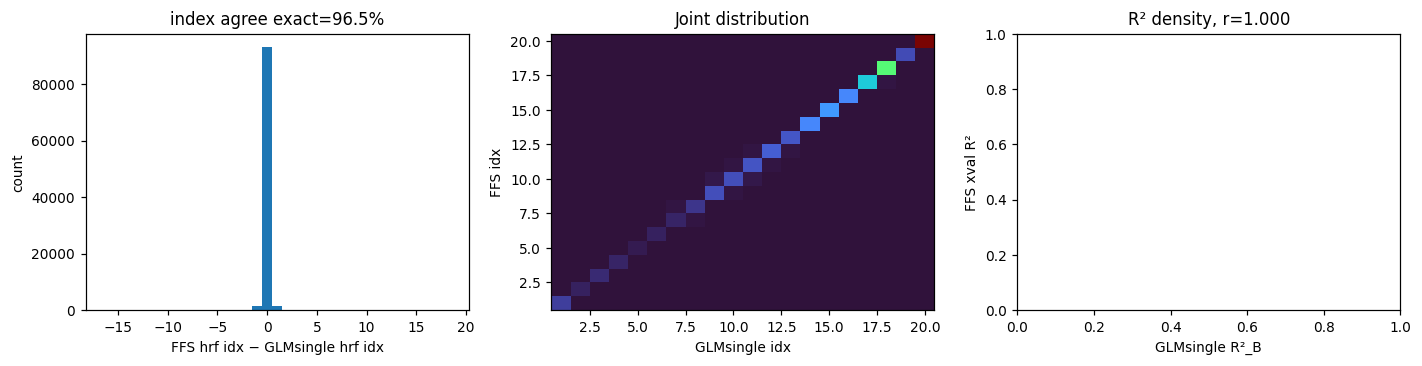

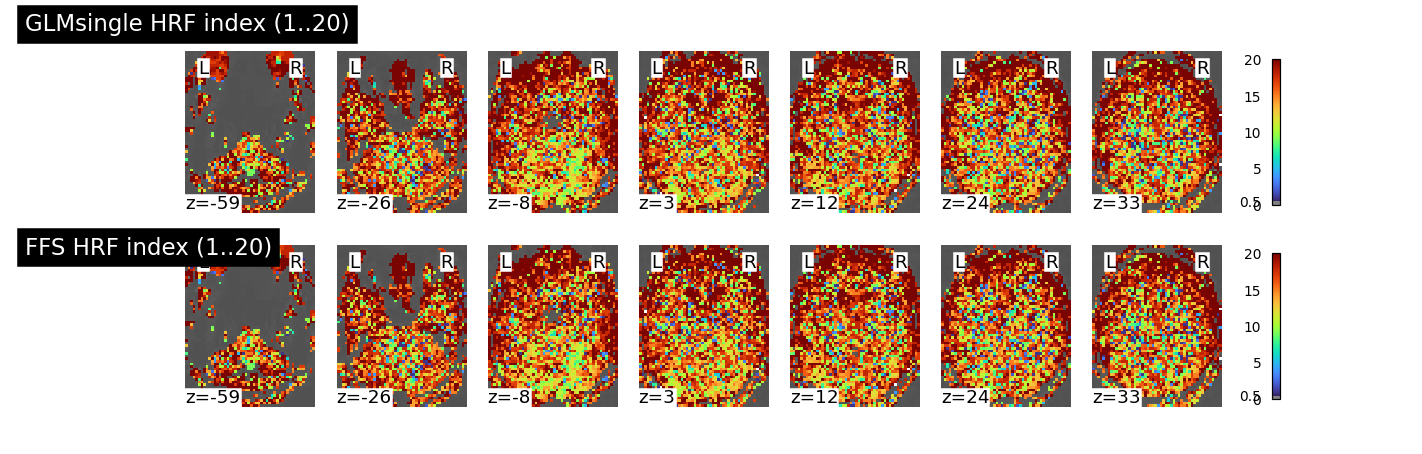

In [243]:
banner('GLMsingle TypeB (HRF library) vs ffs_hrfopt',
       'HRF index agreement ≥ 0.50, R² r ≥ 0.85')

gs = DATA_ROOT / 'glmsingle'
ffs = DATA_ROOT / 'ffs_hrfopt'
ml_idx, aff_idx = load_vol(gs / 'glmsingle_hrf_index.nii.gz')
ml_r2,  aff_r2  = load_vol(gs / 'glmsingle_r2_B.nii.gz')
ml_mask, _ = load_vol(gs / 'glmsingle_mask.nii.gz')
ff_idx, aff_ffidx = load_vol(ffs / 'hrfopt_hrf_index.nii.gz')
ff_r2,  aff_ffr2  = load_vol(ffs / 'hrfopt_xval_r2.nii.gz')

# MNI-space mean EPI underlay (same grid as GLMsingle outputs)
bg_path = PROC / 'mean_this_localizer.nii.gz'
bg_img = nib.load(str(bg_path)) if bg_path.exists() else None

mask = (ml_mask > 0.5) & (ff_r2 > 0)
ml_idx_m = ml_idx[mask]; ff_idx_m = ff_idx[mask]
if ff_idx_m.min() == 0 and ml_idx_m.min() == 1:
    ff_idx_m = ff_idx_m + 1
agreement = (ml_idx_m == ff_idx_m).mean()
diff = ff_idx_m - ml_idx_m
r2_r = spatial_r(ml_r2, ff_r2, mask)
print(f'HRF index exact-match: {agreement:.1%},  |Δidx|≤1: {(np.abs(diff)<=1).mean():.1%}')
print(f'R² spatial r:          {r2_r:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].hist(diff, bins=np.arange(diff.min()-0.5, diff.max()+1.5), color='C0')
axes[0].set(xlabel='FFS hrf idx − GLMsingle hrf idx', ylabel='count',
            title=f'index agree exact={agreement:.1%}')
axes[1].hist2d(ml_idx_m, ff_idx_m,
               bins=[np.arange(0.5, ml_idx_m.max()+1.5),
                     np.arange(0.5, ff_idx_m.max()+1.5)],
               cmap='turbo')
axes[1].set(xlabel='GLMsingle idx', ylabel='FFS idx', title='Joint distribution')
axes[2].hexbin(ml_r2[mask], ff_r2[mask], gridsize=60, cmap='viridis',
               mincnt=1, bins='log', extent=(0, 1, 0, 1))
axes[2].plot([0, 1], [0, 1], 'w--', lw=0.7)
axes[2].set(xlabel='GLMsingle R²_B', ylabel='FFS xval R²',
            title=f'R² density, r={r2_r:.3f}', xlim=(0, 1), ylim=(0, 1))
plt.tight_layout(); plt.show()


# Pretty HRF-index maps with turbo cmap (which HRF was picked at each voxel)
ml_idx_show = np.where(mask, ml_idx, 0)
ff_idx_show = np.where(mask, ff_idx + (1 if ff_idx[mask].min() == 0 else 0), 0)
n_hrf = max(int(ml_idx_show.max()), int(ff_idx_show.max()))
img_a_idx = array_to_img(ml_idx_show, aff_idx)
img_f_idx = array_to_img(ff_idx_show, aff_ffidx)
if HAS_NILEARN and bg_img is not None:
    fig = plt.figure(figsize=(13, 4.2))
    ax_a = fig.add_subplot(2, 1, 1); ax_b = fig.add_subplot(2, 1, 2)
    kw = dict(bg_img=bg_img, threshold=0.5, cmap='turbo', vmax=n_hrf,
              symmetric_cbar=False, display_mode='z', cut_coords=7,
              draw_cross=False, black_bg=False, colorbar=True)
    niplot.plot_stat_map(img_a_idx, axes=ax_a,
                         title=f'GLMsingle HRF index (1..{n_hrf})', **kw)
    niplot.plot_stat_map(img_f_idx, axes=ax_b,
                         title=f'FFS HRF index (1..{n_hrf})',       **kw)
    plt.tight_layout(); plt.show()
else:
    show_axial_pair(ml_idx_show, ff_idx_show,
                    'GLMsingle HRF index', 'FFS HRF index',
                    cmap='turbo', threshold = None, vmin=0, vmax=n_hrf)

## 12. GLMsingle Type-C (denoising) vs ffs_denoise

**Pass**: PC count ±2, noisepool Jaccard ≥ 0.5, xvaltrend r ≥ 0.85.


──────────────────────────────────────────────────────────────────────────────
  GLMsingle TypeC (denoise) vs ffs_denoise
  PASS criterion: PC count ±2, noisepool Jaccard ≥ 0.5, xvaltrend r ≥ 0.85
──────────────────────────────────────────────────────────────────────────────
PC count:        GLMsingle=8, FFS=7
Noisepool size:  GLMsingle=69657, FFS=86368, Jaccard=0.792
xvaltrend r (shape only): -0.8256


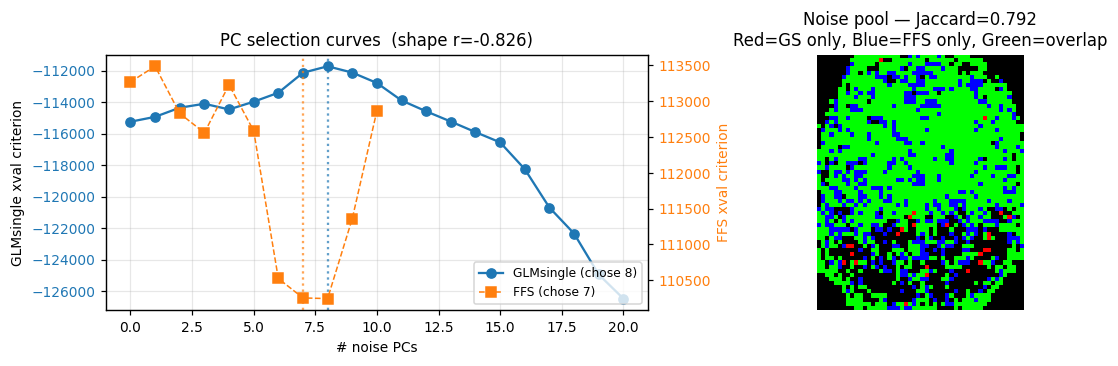

In [244]:
banner('GLMsingle TypeC (denoise) vs ffs_denoise',
       'PC count ±2, noisepool Jaccard ≥ 0.5, xvaltrend r ≥ 0.85')

ff = DATA_ROOT / 'ffs_denoise'
ml_pcnum = int((gs / 'glmsingle_pcnum.txt').read_text().strip())
ml_xv = np.loadtxt(gs / 'glmsingle_xvaltrend.txt')
with open(ff / 'denoise_denoise_metadata.json') as fh:
    ff_meta = json.load(fh)
ff_pcnum = ff_meta.get('optimal_pcs', -1)
ff_xv = np.load(ff / 'denoise_pc_selection_curve.npy')

ml_np, _ = load_vol(gs / 'glmsingle_noisepool.nii.gz')
ff_np, _ = load_vol(ff / 'denoise_noise_pool_mask.nii.gz')
ml_np = ml_np > 0.5; ff_np = ff_np > 0.5
jacc = (ml_np & ff_np).sum() / max((ml_np | ff_np).sum(), 1)
L = min(len(ml_xv), len(ff_xv))
xv_r = np.corrcoef(ml_xv[:L], ff_xv[:L])[0, 1]

print(f'PC count:        GLMsingle={ml_pcnum}, FFS={ff_pcnum}')
print(f'Noisepool size:  GLMsingle={ml_np.sum()}, FFS={ff_np.sum()}, Jaccard={jacc:.3f}')
print(f'xvaltrend r (shape only): {xv_r:.4f}')

# PC curves are on different absolute scales — twin axes so the *shapes* compare.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax_l = axes[0]
ax_r = ax_l.twinx()
l1, = ax_l.plot(np.arange(len(ml_xv)), ml_xv, 'o-', color='C0', lw=1.5, label='GLMsingle')
l2, = ax_r.plot(np.arange(len(ff_xv)), ff_xv, 's--', color='C1', lw=1.0, label='FFS')
ax_l.axvline(ml_pcnum, color='C0', ls=':', alpha=0.7)
ax_r.axvline(ff_pcnum, color='C1', ls=':', alpha=0.7)
ax_l.set(xlabel='# noise PCs', ylabel='GLMsingle xval criterion',
         title=f'PC selection curves  (shape r={xv_r:.3f})')
ax_l.tick_params(axis='y', labelcolor='C0')
ax_r.set_ylabel('FFS xval criterion', color='C1'); ax_r.tick_params(axis='y', labelcolor='C1')
ax_l.grid(alpha=0.3)
ax_l.legend([l1, l2], [f'GLMsingle (chose {ml_pcnum})', f'FFS (chose {ff_pcnum})'],
            loc='lower right', fontsize=8)

# Noise pool overlap on a slice
z = ml_np.shape[2] // 2
ml_s = ml_np[..., z].astype(bool)
ff_s = ff_np[..., z].astype(bool)

both = ml_s & ff_s
ml_only = ml_s & ~ff_s
ff_only = ff_s & ~ml_s

ov = np.zeros((*ml_s.shape, 3), dtype=np.float32)
ov[..., 0] = ml_only   # red
ov[..., 1] = both      # green
ov[..., 2] = ff_only   # blue

axes[1].imshow(ov.transpose(1, 0, 2), origin='lower', interpolation='nearest')
axes[1].set_title(f'Noise pool — Jaccard={jacc:.3f}\nRed=GS only, Blue=FFS only, Green=overlap')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# TODO - this should have the same single trial correlations map as the ridge regression, assumign we have the betas, and then show a map for best correlationa and lowest. Thresholding is tricky buy eh. 

## 13. GLMsingle Type-D (fracridge) vs ffs_ridge

**Pass**: per-voxel optimal fraction r ≥ 0.5; β median trial-spatial r ≥ 0.85.


──────────────────────────────────────────────────────────────────────────────
  GLMsingle TypeD (fracridge) vs ffs_ridge
  PASS criterion: frac r ≥ 0.5, β median spatial r ≥ 0.85
──────────────────────────────────────────────────────────────────────────────
Optimal fraction spatial r (frac>0 voxels): 0.9941
  n voxels with frac>0 in both: 67082


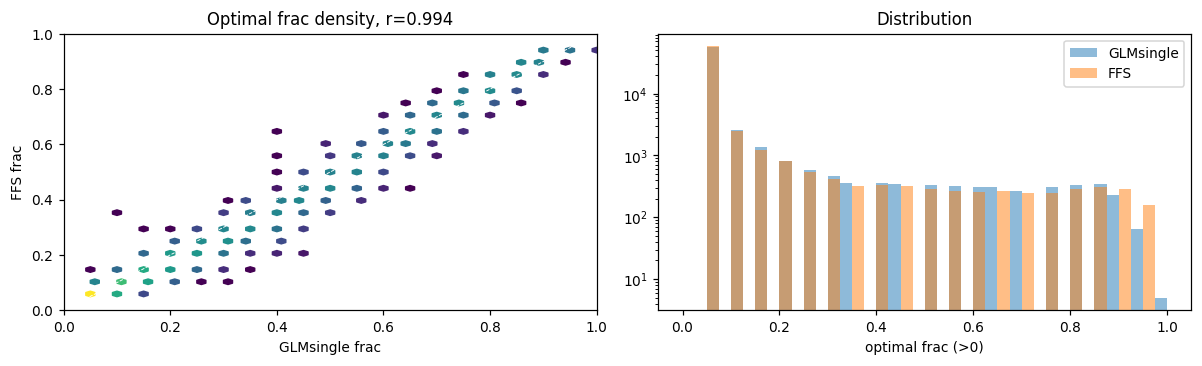

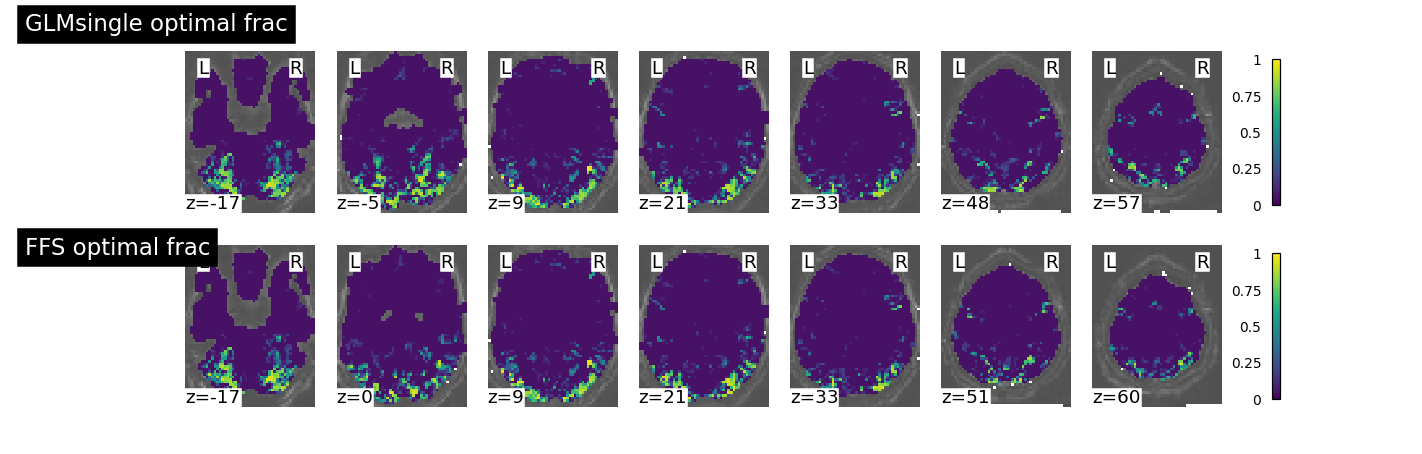

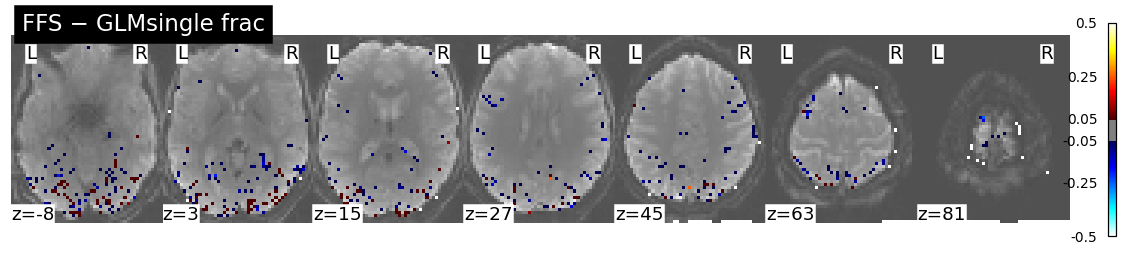

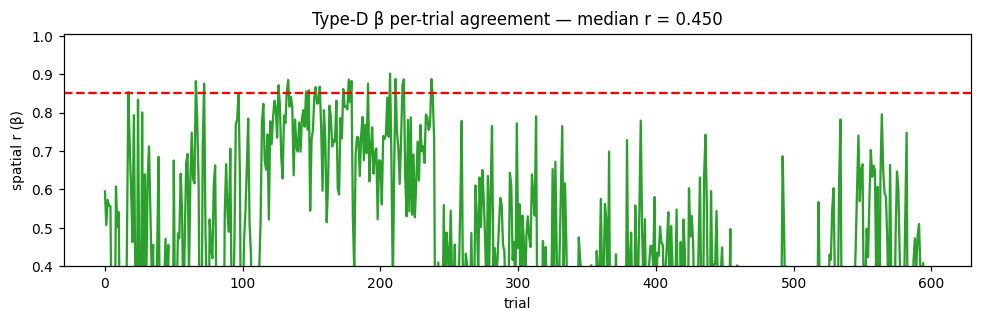


──────────────────────────────────────────────────────────────────────────────
   Poor spatial is likely due to different scaling (overall mean versus per run)
──────────────────────────────────────────────────────────────────────────────
Max β spatial r: 0.9015 at trial index 207


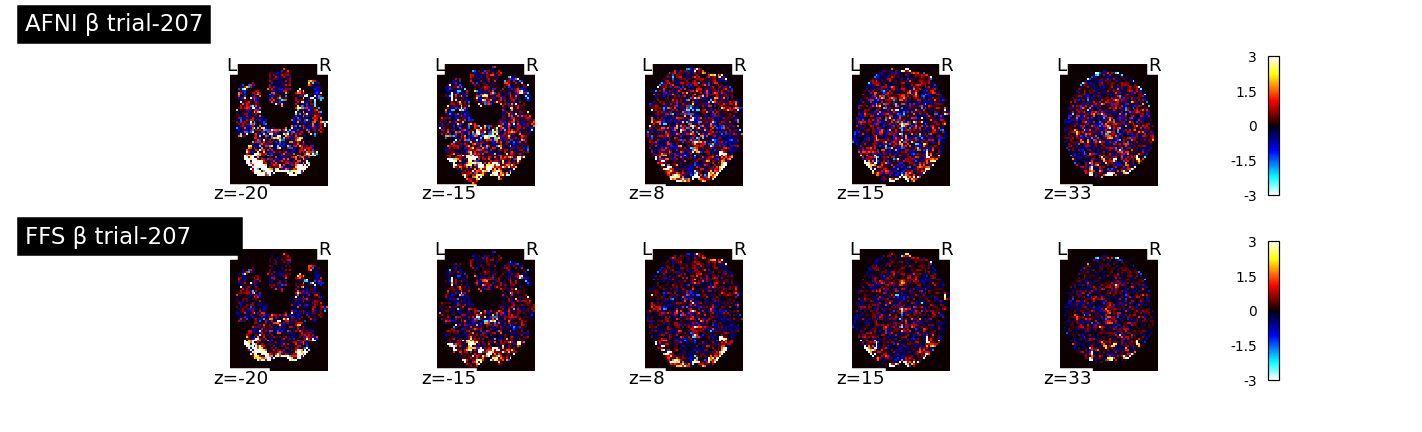

Min β spatial r: -0.2596 at trial index 47


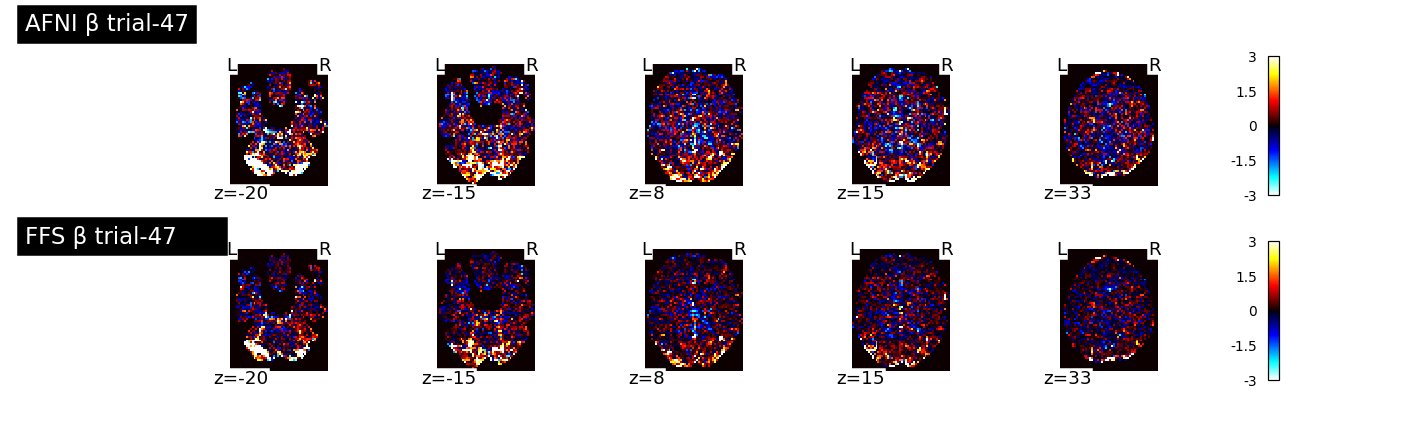

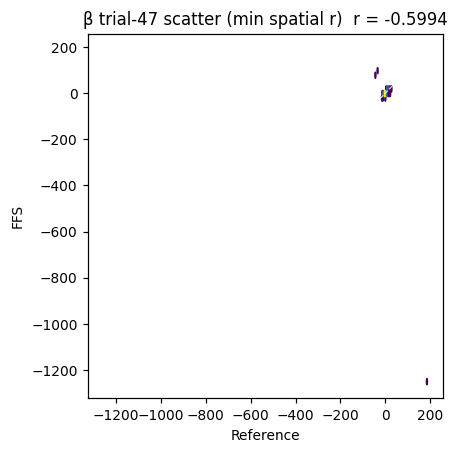

np.float64(-0.5994243429783704)

In [245]:
banner("GLMsingle TypeD (fracridge) vs ffs_ridge", "frac r ≥ 0.5, β median spatial r ≥ 0.85")

ff = DATA_ROOT / "ffs_ridge"
ml_frac, aff_mf = load_vol(gs / "glmsingle_fracvalue.nii.gz")
ff_frac, aff_ff = load_vol(ff / "ridge_optimal_frac.nii.gz")
# ml_mask, _ = load_vol(gs / 'glmsingle_mask.nii.gz')
# use the MNI automask, not whatever this tried to do.
ml_mask, _ = load_vol(DATA_ROOT / "processing" / "MNI_automask.nii.gz")
mask = ml_mask == 1
# Drop frac == 0 voxels — those are background, not "no regularization".
# (a true 'no-regularization' choice would be frac == 1, the OLS limit.)
# mask = (ml_mask > 0.5) & np.isfinite(ml_frac) & np.isfinite(ff_frac) \
#        & (ff_frac > 0) & (ml_frac > 0)
frac_r = spatial_r(ml_frac, ff_frac, mask)
print(f"Optimal fraction spatial r (frac>0 voxels): {frac_r:.4f}")
print(f"  n voxels with frac>0 in both: {int(mask.sum())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hexbin(
    ml_frac[mask],
    ff_frac[mask],
    gridsize=60,
    cmap="viridis",
    mincnt=1,
    bins="log",
    extent=(0, 1, 0, 1),
)
axes[0].plot([0, 1], [0, 1], "w--", lw=0.6)
axes[0].set(
    xlabel="GLMsingle frac",
    ylabel="FFS frac",
    title=f"Optimal frac density, r={frac_r:.3f}",
    xlim=(0, 1),
    ylim=(0, 1),
)

axes[1].hist(ml_frac[mask], bins=np.linspace(0, 1, 41), alpha=0.5, label="GLMsingle", color="C0")
axes[1].hist(ff_frac[mask], bins=np.linspace(0, 1, 41), alpha=0.5, label="FFS", color="C1")
axes[1].set_yscale("log")
axes[1].set(xlabel="optimal frac (>0)", title="Distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

# MNI rendering: mask out frac==0 so the maps highlight only ridge-relevant voxels
ml_show = np.where(mask, ml_frac, np.nan)
ff_show = np.where(mask, ff_frac, np.nan)
ml_img = array_to_img(np.where(mask, ml_frac, 0), aff_mf)
ff_img = array_to_img(np.where(mask, ff_frac, 0), aff_ff)
diff_img = array_to_img(np.where(mask, ff_frac - ml_frac, 0), aff_ff)

if HAS_NILEARN and bg_img is not None:
    fig = plt.figure(figsize=(13, 4.2))
    ax_a = fig.add_subplot(2, 1, 1)
    ax_b = fig.add_subplot(2, 1, 2)
    kw = dict(
        bg_img=bg_img,
        threshold=1e-6,
        cmap="viridis",
        vmax=1.0,
        symmetric_cbar=False,
        display_mode="z",
        cut_coords=7,
        draw_cross=False,
        black_bg=False,
        colorbar=True,
    )
    niplot.plot_stat_map(ml_img, axes=ax_a, title="GLMsingle optimal frac", **kw)
    niplot.plot_stat_map(ff_img, axes=ax_b, title="FFS optimal frac", **kw)
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(13, 2.8))
    ax = fig.add_subplot(1, 1, 1)
    niplot.plot_stat_map(
        diff_img,
        axes=ax,
        title="FFS − GLMsingle frac",
        bg_img=bg_img,
        threshold=0.05,
        cmap="cold_hot",
        vmax=0.5,
        display_mode="z",
        cut_coords=7,
        draw_cross=False,
        black_bg=False,
        colorbar=True,
    )
    plt.show()
else:
    pretty_stat_pair(
        ml_img,
        ff_img,
        "GLMsingle frac",
        "FFS frac",
        threshold=1e-6,
        cmap="viridis",
        vmax=1.0,
        display_mode="z",
    )

# Type-D betas — per-trial spatial r
ml_b, _ = load_vol(gs / "glmsingle_betas_D.nii.gz")
ff_b, _ = load_vol(ff / "ridge_single_trial_betas.nii.gz")
n_tr = min(ml_b.shape[-1], ff_b.shape[-1])
rs = [spatial_r(ml_b[..., i], ff_b[..., i], mask) for i in range(n_tr)]
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(rs, color="C2")
ax.axhline(0.85, color="red", ls="--")
ax.set(
    xlabel="trial",
    ylabel="spatial r (β)",
    title=f"Type-D β per-trial agreement — median r = {np.median(rs):.3f}",
    ylim=(0.4, 1.005),
)
plt.tight_layout()
plt.show()

line = '─' * 78
print(f'\n{line}\n   Poor spatial is likely due to different scaling (overall mean versus per run)\n{line}')


# Lets find the max and min of the beta_rs so we can look at those.
max_idx = np.argmax(rs)
min_idx = np.argmin(rs)
print(f"Max β spatial r: {rs[max_idx]:.4f} at trial index {max_idx}")
# Pretty MNI overlay of trial-1 β and the F-stat
max_img_a_b1 = array_to_img(np.where(mask, ml_b[..., max_idx], 0), aff_mf)
max_img_f_b1 = array_to_img(np.where(mask, ff_b[..., max_idx], 0), aff_ff)
pretty_stat_pair(
    max_img_a_b1,
    max_img_f_b1,
    f"AFNI β trial-{max_idx}",
    f"FFS β trial-{max_idx}      ",
    threshold=None,
    cmap="cold_hot",
    display_mode="z",
    vmax=3,
    cut_coords=(-20,-15, 8, 15,33) if HAS_NILEARN else None,
)

print(f"Min β spatial r: {rs[min_idx]:.4f} at trial index {min_idx}")
# Pretty MNI overlay of trial-1 β and the F-stat
min_img_a_b1 = array_to_img(np.where(mask, ml_b[..., min_idx], 0), aff_mf)
min_img_f_b1 = array_to_img(np.where(mask, ff_b[..., min_idx], 0), aff_ff)
pretty_stat_pair(
    min_img_a_b1,
    min_img_f_b1,
    f"AFNI β trial-{min_idx}",
    f"FFS β trial-{min_idx}      ",
    threshold=None,
    cmap="cold_hot",
    display_mode="z",
    vmax=3,
    cut_coords=(-20,-15, 8, 15,33)  if HAS_NILEARN else None,
)

# Lets scatter the betas against each other in the min_imgs 
scatter_voxels(ml_b[..., min_idx], ff_b[..., min_idx], mask, title=f'β trial-{min_idx} scatter (min spatial r)')

# TODO scatter plo doesn't agree with spatial correlation. Eyeballs say it is fine, so for now, I think ffs_ridge is ok
# TODO - ffs_ridge is hammering CPU, wtf? ddespite device cuda. something wrong?


Mean temporal correlation (β): 0.9809
Median temporal correlation (β): 0.9888


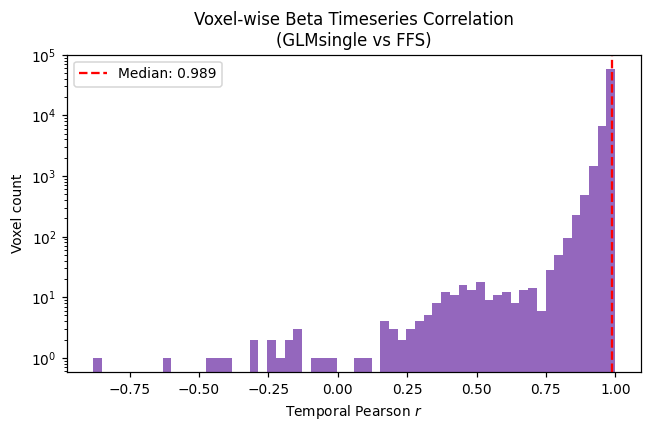

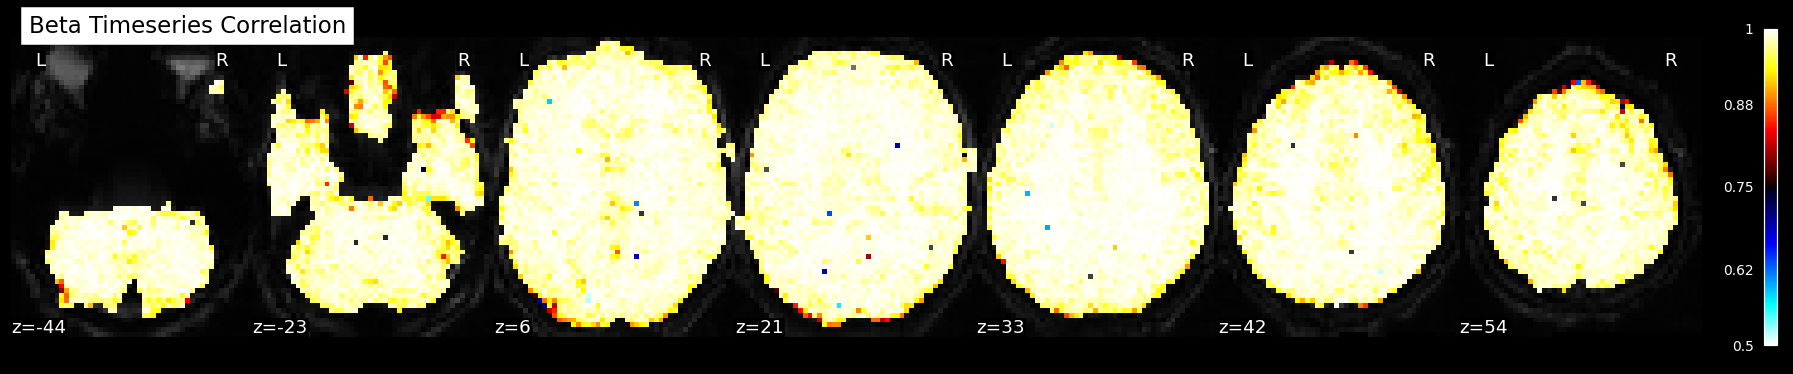

In [246]:
# Calculate voxel-wise temporal correlation for betas within the mask
n_trials = min(ml_b.shape[-1], ff_b.shape[-1])
ml_ts = ml_b[mask, :n_trials]
ff_ts = ff_b[mask, :n_trials]

# Demean and standardize to compute correlation quickly
ml_z = (ml_ts - ml_ts.mean(axis=-1, keepdims=True)) / (ml_ts.std(axis=-1, keepdims=True) + 1e-8)
ff_z = (ff_ts - ff_ts.mean(axis=-1, keepdims=True)) / (ff_ts.std(axis=-1, keepdims=True) + 1e-8)
beta_ts_corr = (ml_z * ff_z).mean(axis=-1)

# Drop any NaN correlations (e.g., from constant timeseries/background)
valid_corr = beta_ts_corr[np.isfinite(beta_ts_corr)]

print(f"Mean temporal correlation (β): {np.mean(valid_corr):.4f}")
print(f"Median temporal correlation (β): {np.median(valid_corr):.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(valid_corr, bins=60, color='C4')
ax.axvline(np.median(valid_corr), color='red', linestyle='--', label=f'Median: {np.median(valid_corr):.3f}')
ax.set(
    xlabel='Temporal Pearson $r$', 
    ylabel='Voxel count', 
    title='Voxel-wise Beta Timeseries Correlation\n(GLMsingle vs FFS)'
)
ax.legend()
plt.yscale('log')
plt.tight_layout()

plt.show()

# Show the spatial distribution of these correlations
corr_map = np.zeros(mask.shape)
corr_map[mask] = beta_ts_corr
corr_img = array_to_img(corr_map, aff_ff)

if HAS_NILEARN and bg_img is not None:
    niplot.plot_stat_map(
        corr_img,
        bg_img=bg_img,
        title="Beta Timeseries Correlation",
        display_mode="z",
        cut_coords=7,
        vmin=0.5,
        vmax=1.0,
        cmap="cold_hot",
        threshold=0.3
    )
    plt.show()


    # TODO this tells the story. For each voxel, it has a very similar temporal pattern. 
    # However the spatial story above shows that the scaling is very different. 
    # This is likely because GLMDenoise scales by the mean at the end, and when we -do_scale we scale by each runs individual mean. 

## 14. NORDIC denoising  *(different dataset)*

NORDIC operates on raw complex (mag + phase) data, so it lives in `test_data/nordic_test_data/`
rather than the `ds005165` benchmark set. Stage `nordic`
(`benchmark/stages/nordic.py`) compares MATLAB `NIFTI_NORDIC` against `ffs_nordic`.

**Pass criteria**
- Median per-voxel timeseries r ≥ 0.95 (noise volumes excluded)
- g-factor map spatial r ≥ 0.99

We visualise:
- per-voxel r distribution across the brain mask
- before / MATLAB-NORDIC / FFS-NORDIC timecourses for several individual voxels
  (one per row, so the noise reduction is obvious)
- g-factor map agreement


──────────────────────────────────────────────────────────────────────────────
  NORDIC (MATLAB NIFTI_NORDIC vs ffs_nordic)
  PASS criterion: median per-voxel timeseries r ≥ 0.95, g-factor r ≥ 0.99
──────────────────────────────────────────────────────────────────────────────
  median per-voxel ts r:  0.9879
  frac > 0.95         :  0.930  (n=1603494)


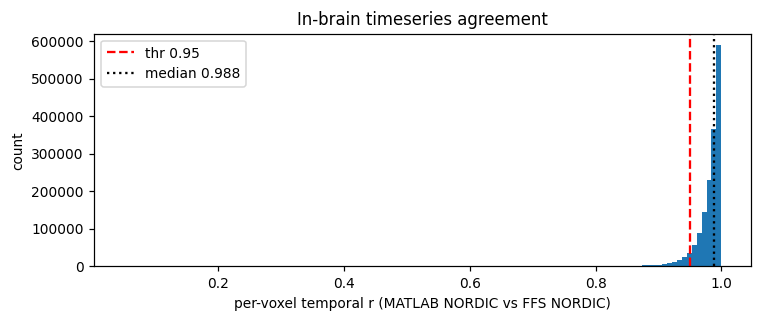

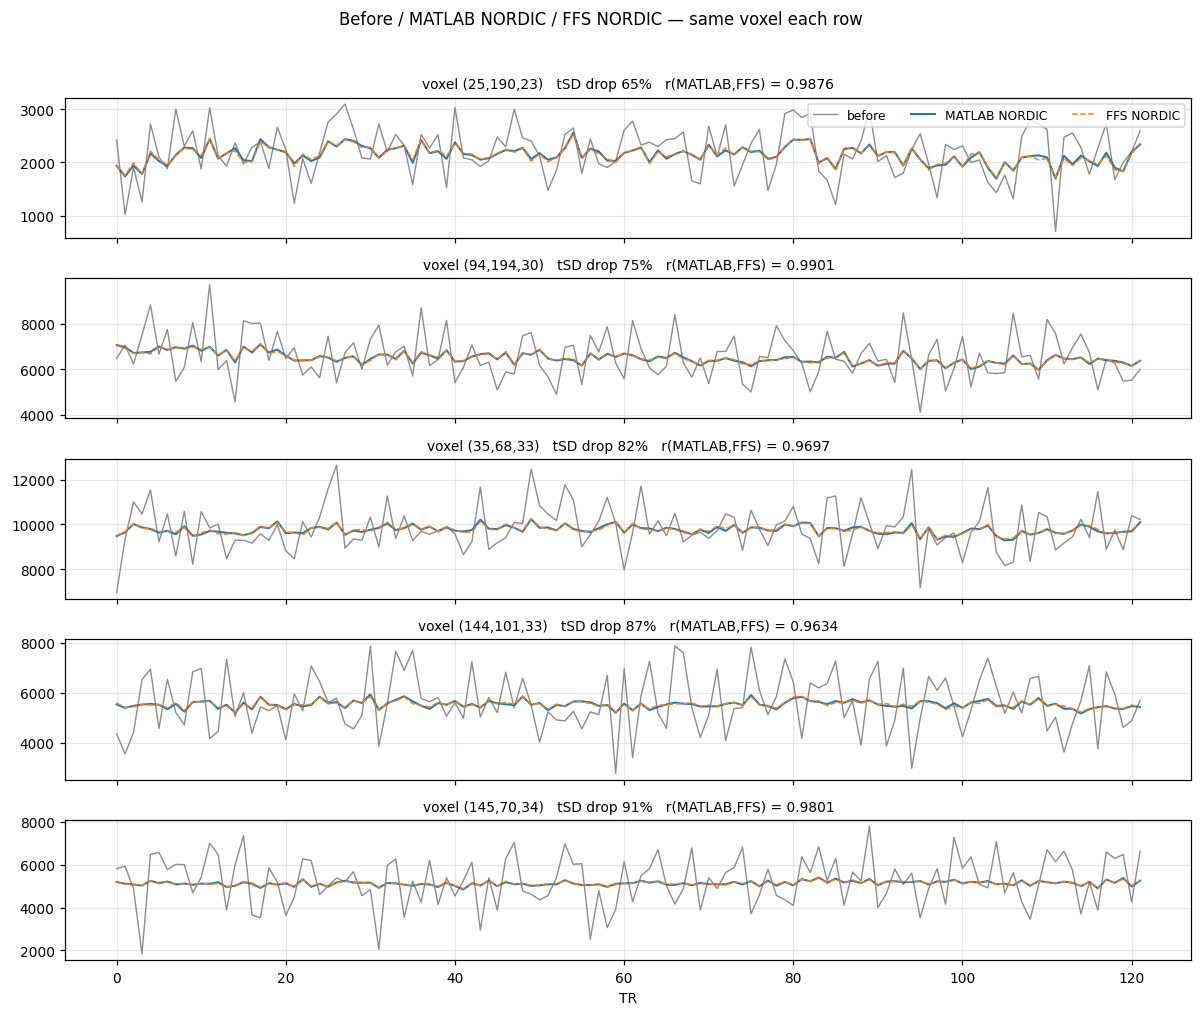

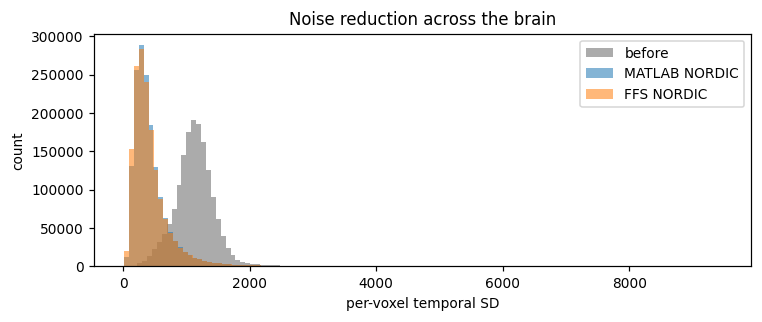


  g-factor spatial r:  0.9998  (thr 0.99)


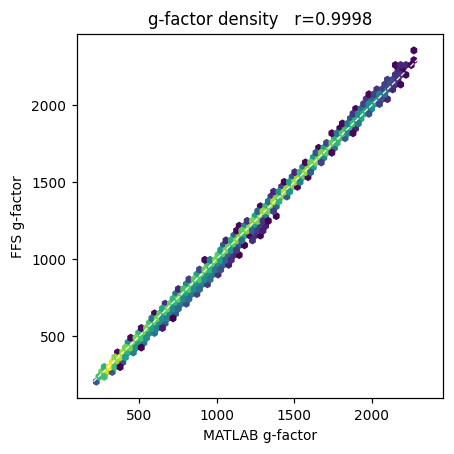

In [247]:
banner('NORDIC (MATLAB NIFTI_NORDIC vs ffs_nordic)',
       'median per-voxel timeseries r ≥ 0.95, g-factor r ≥ 0.99')

NORDIC_DIR = DATA_ROOT.parent / 'nordic_test_data'
NOISE_VOLS = 3
RAW_PATH = NORDIC_DIR / 'sub-3003_ses-fine_task-expres_run-1_part-mag_bold.nii.gz'
REF_PATH = NORDIC_DIR / 'NORDIC_sub-3003_ses-fine_task-expres_run-1_part-mag_bold.nii'
FFS_PATH = NORDIC_DIR / 'ffs_nordic_defaults.nii.gz'
REF_GF   = NORDIC_DIR / 'gfactor_NORDIC_sub-3003_ses-fine_task-expres_run-1_part-mag_bold.nii'
FFS_GF   = NORDIC_DIR / 'ffs_nordic_defaults_gfactor.nii.gz'

if not all(p.exists() for p in [RAW_PATH, REF_PATH, FFS_PATH]):
    print('NORDIC inputs/outputs missing; skipping section')
else:
    raw, _ = load_vol(RAW_PATH)
    ref, _ = load_vol(REF_PATH)
    ffs_, _ = load_vol(FFS_PATH)

    # Drop trailing noise volumes
    keep = ref.shape[-1] - NOISE_VOLS
    raw  = raw[..., :keep]
    ref  = ref[..., :keep]
    ffs_ = ffs_[..., :keep]

    # In-brain mask: voxels with non-trivial timeseries
    mask = ref.std(axis=-1) > 0
    mask &= automask(ref.mean(-1))

    # ── per-voxel temporal r between MATLAB and FFS NORDIC ──
    av = ref[mask]; bv = ffs_[mask]
    az = av - av.mean(1, keepdims=True); bz = bv - bv.mean(1, keepdims=True)
    denom = np.sqrt((az**2).sum(1) * (bz**2).sum(1))
    ok = denom > 0
    rs = (az[ok] * bz[ok]).sum(1) / denom[ok]
    median_r = float(np.median(rs))
    frac_above = float((rs > 0.95).mean())
    print(f'  median per-voxel ts r:  {median_r:.4f}')
    print(f'  frac > 0.95         :  {frac_above:.3f}  (n={ok.sum()})')

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(rs, bins=120, color='C0')
    ax.axvline(0.95, color='red', ls='--', label='thr 0.95')
    ax.axvline(median_r, color='k',   ls=':',  label=f'median {median_r:.3f}')
    ax.set(xlabel='per-voxel temporal r (MATLAB NORDIC vs FFS NORDIC)',
           ylabel='count', title='In-brain timeseries agreement')
    ax.legend(); plt.tight_layout(); plt.show()

    # ── per-voxel timecourses: pick voxels spanning the SNR range ──
    # Quantify "how much noise NORDIC removed" per voxel: tSD reduction.
    raw_sd = raw.std(-1)
    ref_sd = ref.std(-1)
    sd_drop = np.where(mask & (raw_sd > 0), 1 - ref_sd / (raw_sd + 1e-12), 0)
    # Pick 5 voxels at a range of denoising amounts
    vox_in_mask = np.argwhere(mask)
    drops = sd_drop[mask]
    qs = np.quantile(drops, [0.5, 0.7, 0.85, 0.95, 0.99])
    chosen = []
    for q in qs:
        idx = int(np.argmin(np.abs(drops - q)))
        chosen.append((tuple(vox_in_mask[idx]), drops[idx]))

    fig, axes = plt.subplots(len(chosen), 1, figsize=(11, 1.8 * len(chosen)),
                             sharex=True)
    for ax, ((x, y, z), drop) in zip(axes, chosen):
        a = raw [x, y, z]
        b = ref [x, y, z]
        c = ffs_[x, y, z]
        ax.plot(a, color='0.55', lw=0.9, label='before')
        ax.plot(b, color='C0',   lw=1.3, label='MATLAB NORDIC')
        ax.plot(c, color='C1',   lw=1.0, ls='--', label='FFS NORDIC')
        r_ab = np.corrcoef(b, c)[0, 1]
        ax.set_title(f'voxel ({x},{y},{z})   '
                     f'tSD drop {drop*100:.0f}%   '
                     f'r(MATLAB,FFS) = {r_ab:.4f}',
                     fontsize=9)
        ax.grid(alpha=0.3)
    axes[0].legend(loc='upper right', fontsize=8, ncol=3)
    axes[-1].set_xlabel('TR')
    fig.suptitle('Before / MATLAB NORDIC / FFS NORDIC — same voxel each row',
                 y=1.02)
    plt.tight_layout(); plt.show()

    # ── overall noise reduction summary ──
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(raw_sd[mask], bins=120, alpha=0.55, label='before',         color='0.4')
    ax.hist(ref_sd[mask], bins=120, alpha=0.55, label='MATLAB NORDIC',  color='C0')
    ax.hist(ffs_[..., :].std(-1)[mask], bins=120, alpha=0.55,
            label='FFS NORDIC', color='C1')
    ax.set(xlabel='per-voxel temporal SD', ylabel='count',
           title='Noise reduction across the brain')
    ax.legend(); plt.tight_layout(); plt.show()

    # ── g-factor map agreement ──
    if REF_GF.exists() and FFS_GF.exists():
        gf_ref, _ = load_vol(REF_GF); gf_ffs, _ = load_vol(FFS_GF)
        gmask = (gf_ref > 0) & (gf_ffs > 0)
        gf_r = float(np.corrcoef(gf_ref[gmask], gf_ffs[gmask])[0, 1])
        print(f'\n  g-factor spatial r:  {gf_r:.4f}  (thr 0.99)')
        fig, ax = plt.subplots(figsize=(4.2, 4.2))
        ax.hexbin(gf_ref[gmask], gf_ffs[gmask], gridsize=60,
                  cmap='viridis', mincnt=1, bins='log')
        lo, hi = float(min(gf_ref[gmask].min(), gf_ffs[gmask].min())), \
                 float(max(gf_ref[gmask].max(), gf_ffs[gmask].max()))
        ax.plot([lo, hi], [lo, hi], 'w--', lw=0.8)
        ax.set(xlabel='MATLAB g-factor', ylabel='FFS g-factor',
               title=f'g-factor density   r={gf_r:.4f}')
        plt.tight_layout(); plt.show()

## 15. Phase regression *(different dataset — ds003427)*

Phase regression removes macrovascular BOLD contamination by regressing
magnitude on phase (Menon 2002, Curtis 2014, Stanley 2021).

**Reference**: phaseprep's `PhaseFitOdr` — scipy.odr with multiprocessing
(faithfully ported in `run_phaseprep_reference.py`).

**FFS**: `ffs_phasereg` with Deming regression, polort=1, no task removal.

**Data**: ds003427 sub-03 checkerboard GE (one run), MC'd magnitude +
unwrapped phase in radians. Prep script: `test_data/phase_stage_prep.sh`.

**Pass criteria**:
- R² map Pearson r ≥ 0.90
- Corrected magnitude (micro signal) median per-voxel ts r ≥ 0.99
- Macro component (vein signal) median per-voxel ts r ≥ 0.90
- Slope map: informational only (not a pass criterion — scipy.odr vs
  closed-form pick different roots in ~80k ill-conditioned voxels,
  but ODR shrinkage makes slopes irrelevant for corrected output)

We visualise:
- Slope and R² scatter plots (reference vs FFS)
- Corrected-magnitude timeseries correlation histogram
- Side-by-side corrected magnitude axial slices
- Per-voxel timecourse overlays at several SNR levels
- ODR inflation factor distribution (diagnostic for ill-conditioned voxels)


──────────────────────────────────────────────────────────────────────────────
  Phase regression (phaseprep scipy.odr vs ffs_phasereg)
  PASS criterion: R² r ≥ 0.90, corrected ts median r ≥ 0.99, macro ts median r ≥ 0.90
──────────────────────────────────────────────────────────────────────────────


Slope:   r=0.7741  (both-nonzero n=878,970 / 896,567)
         median |Δ|=0.9844
         ref zeros: 0, ffs zeros: 1,203


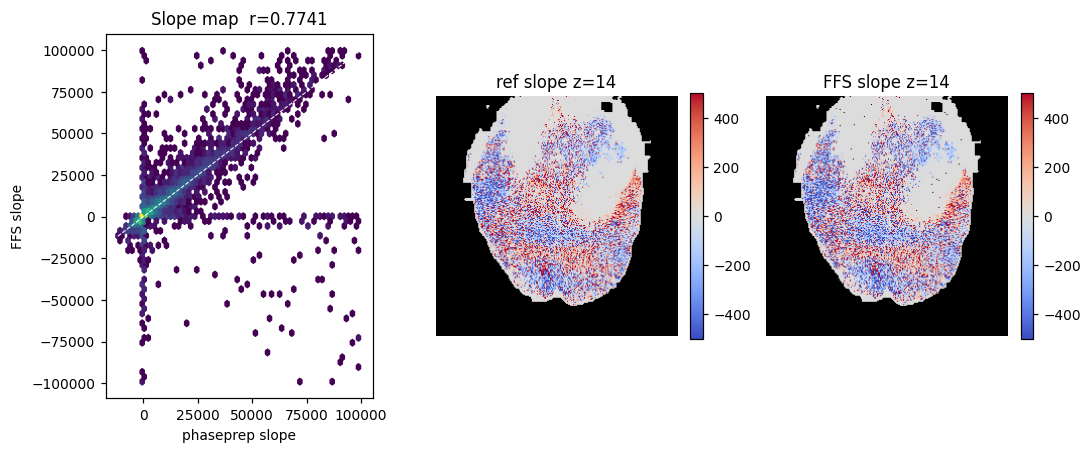

R²:      r=0.9631


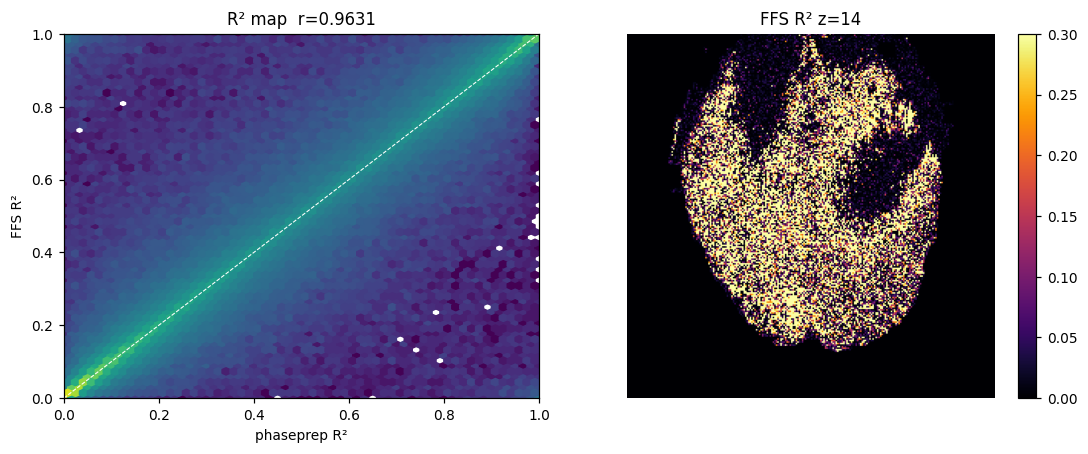

Corrected mag:  median per-voxel ts r = 1.0000
Macro component: median per-voxel ts r = 0.9082


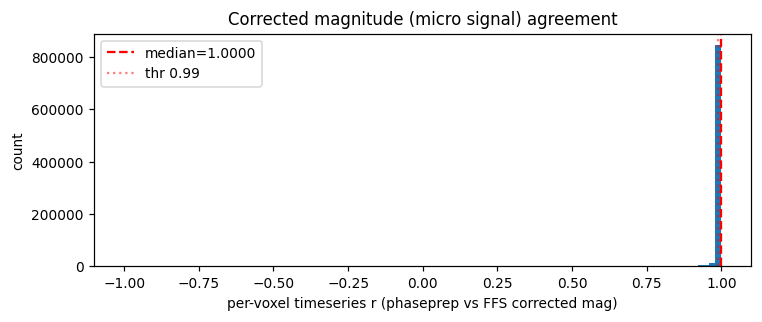

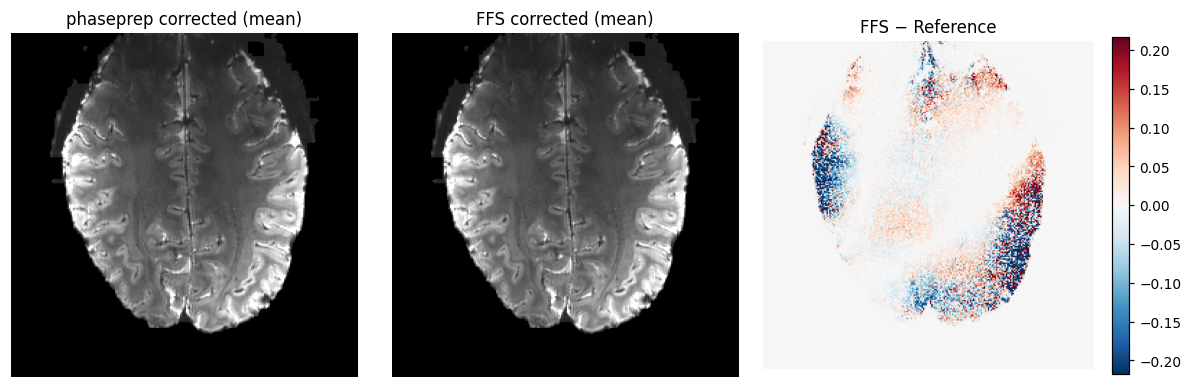

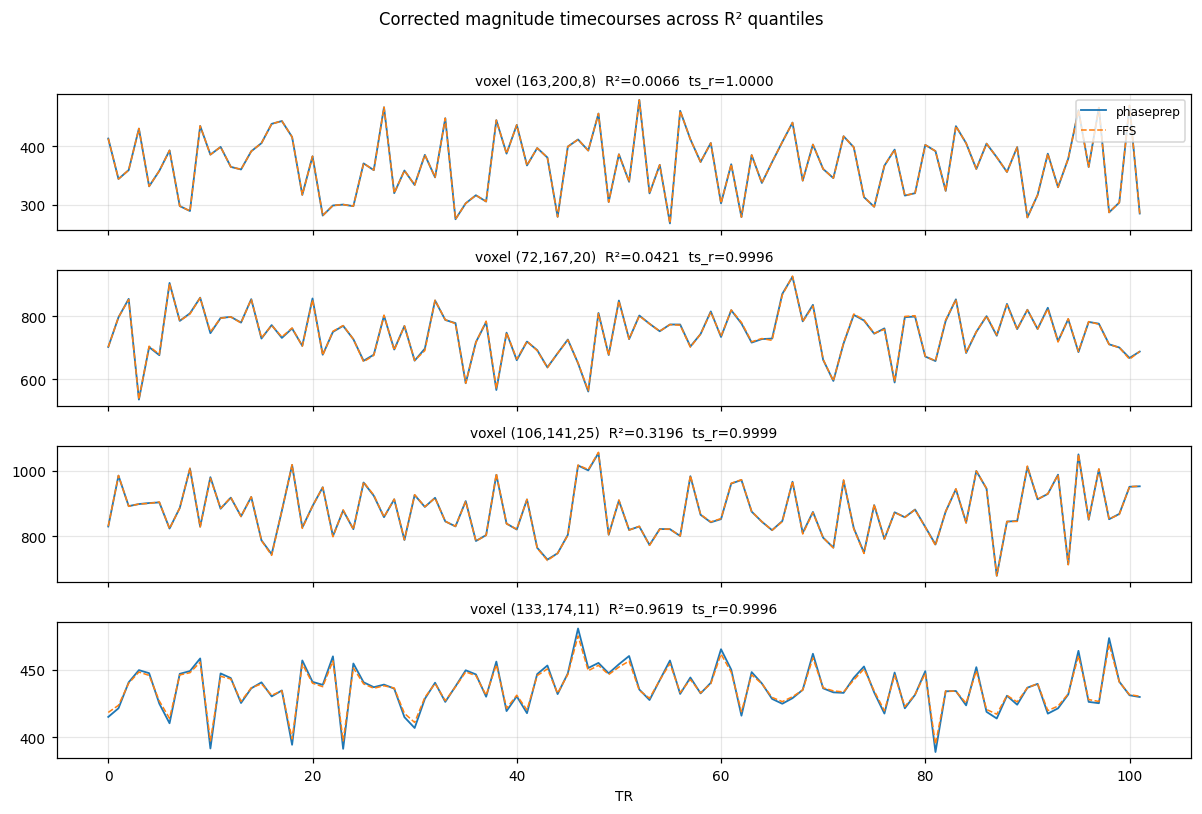

  inflation > 2: 152,555 voxels (17.33%)
  inflation > 5: 90,457 voxels (10.28%)
  inflation > 10: 62,122 voxels (7.06%)


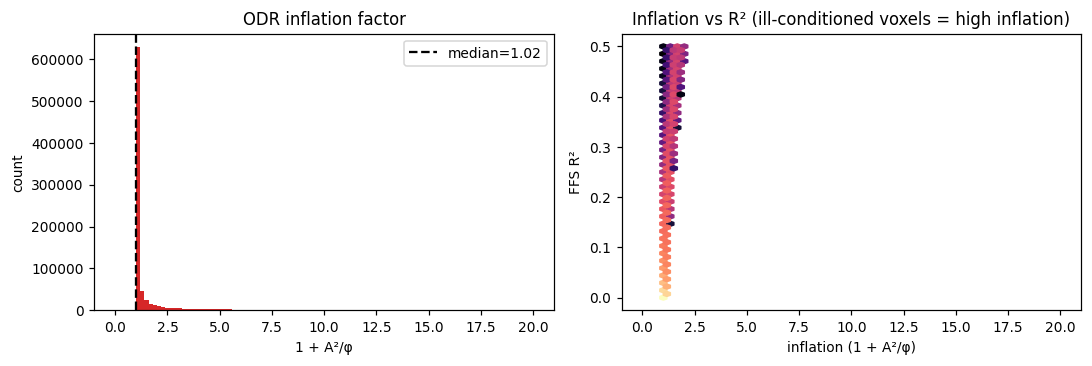

In [248]:
banner(
    "Phase regression (phaseprep scipy.odr vs ffs_phasereg)",
    "R² r ≥ 0.90, corrected ts median r ≥ 0.99, macro ts median r ≥ 0.90",
)

PH_DIR = DATA_ROOT.parent / "ds003427-download" / "processing"
REF_PFX = "phaseprep_ref"
FFS_PFX = "benchmark_ffs_pr"


def pload(suffix):
    return nib.load(str(PH_DIR / f"{suffix}.nii.gz")).get_fdata(dtype=np.float32)


if not (PH_DIR / f"{REF_PFX}_slope.nii.gz").exists():
    print("Phase regression outputs missing; skipping section")
    print(f"  Expected: {PH_DIR / REF_PFX}_slope.nii.gz")
    print(f"  Run: ffs_benchmark -stages phasereg")
else:
    mask = pload("automask").astype(bool)
    n_mask = int(mask.sum())

    ref_slope = pload(f"{REF_PFX}_slope")
    ffs_slope = pload(f"{FFS_PFX}_slope")
    ref_r2 = pload(f"{REF_PFX}_r2")
    ffs_r2 = pload(f"{FFS_PFX}_r2")
    ref_corr = pload(f"{REF_PFX}_corrected")
    ffs_corr = pload(f"{FFS_PFX}_corrected")
    ref_macro = pload(f"{REF_PFX}_macro")
    ffs_macro = pload(f"{FFS_PFX}_macro")
    # We need to mask additionally by extreme values - anything above 1e6 in either one, should be excluded
    mask &= (np.abs(ref_slope) < 1e5) & (np.abs(ffs_slope) < 1e5)
    # ── Slope comparison ──
    rs, fs = ref_slope[mask], ffs_slope[mask]
    both_nz = (rs != 0) & (fs != 0)
    slope_r = np.corrcoef(rs[both_nz], fs[both_nz])[0, 1] if both_nz.sum() > 10 else 0
    slope_med_diff = np.median(np.abs(rs - fs))

    print(f"Slope:   r={slope_r:.4f}  (both-nonzero n={int(both_nz.sum()):,} / {n_mask:,})")
    print(f"         median |Δ|={slope_med_diff:.4f}")
    print(f"         ref zeros: {int((rs == 0).sum()):,}, ffs zeros: {int((fs == 0).sum()):,}")

    fig, axes = plt.subplots(1, 3, figsize=(10, 4.2))
    axes[0].hexbin(rs[both_nz], fs[both_nz], gridsize=60, cmap="viridis", mincnt=1, bins="log")
    lo, hi = rs[both_nz].min(), rs[both_nz].max()
    axes[0].plot([lo, hi], [lo, hi], "w--", lw=0.7)
    axes[0].set(xlabel="phaseprep slope", ylabel="FFS slope", title=f"Slope map  r={slope_r:.4f}")
    # Slope axial slices
    # I want to plot the ref and ffs slope. it should be a diverging color bar - but only pure zero values should be blacked out (black, not center of color bar, low values in the slope should be middling values in colorbad)

    z = ref_slope.shape[2] // 2
    
    # Set exact zeros to NaN so they plot as black
    ref_slope_plot = np.where(ref_slope[..., z].T == 0, np.nan, ref_slope[..., z].T)
    ffs_slope_plot = np.where(ffs_slope[..., z].T == 0, np.nan, ffs_slope[..., z].T)
    
    # Create colormap with bad values (NaN) set to black
    cmap = plt.get_cmap("coolwarm").copy()
    cmap.set_bad(color="black")

    im0 = axes[1].imshow(ref_slope_plot, cmap=cmap, origin="lower", vmin=-500, vmax=500)
    axes[1].set_title(f"ref slope z={z}")
    axes[1].axis("off")
    plt.colorbar(im0, ax=axes[1], fraction=0.046)

    im1 = axes[2].imshow(ffs_slope_plot, cmap=cmap, origin="lower", vmin=-500, vmax=500)
    axes[2].set_title(f"FFS slope z={z}")
    axes[2].axis("off")
    plt.colorbar(im1, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

    # ── R² comparison ──
    rr, fr = ref_r2[mask], ffs_r2[mask]
    r2_r = np.corrcoef(rr, fr)[0, 1] if rr.std() > 0 else 0
    print(f"R²:      r={r2_r:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    axes[0].hexbin(rr, fr, gridsize=60, cmap="viridis", mincnt=1, bins="log")
    axes[0].plot([0, 1], [0, 1], "w--", lw=0.7)
    axes[0].set(
        xlabel="phaseprep R²",
        ylabel="FFS R²",
        title=f"R² map  r={r2_r:.4f}",
        xlim=(0, 1),
        ylim=(0, 1),
    )
    # R² axial slices
    im1 = axes[1].imshow(ffs_r2[..., z].T, cmap="inferno", origin="lower", vmin=0, vmax=0.3)
    axes[1].set_title(f"FFS R² z={z}")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    plt.tight_layout()
    plt.show()

    # ── Corrected magnitude (micro signal) ──
    def ts_corr_median(a4d, b4d, m):
        a = a4d.reshape(-1, a4d.shape[-1])[m.ravel()]
        b = b4d.reshape(-1, b4d.shape[-1])[m.ravel()]
        am = a - a.mean(1, keepdims=True)
        bm = b - b.mean(1, keepdims=True)
        d = np.sqrt((am**2).sum(1) * (bm**2).sum(1))
        ok = d > 0
        return np.median((am[ok] * bm[ok]).sum(1) / d[ok]) if ok.any() else 0.0

    corr_med_r = ts_corr_median(ref_corr, ffs_corr, mask)
    macro_med_r = ts_corr_median(ref_macro, ffs_macro, mask)
    print(f"Corrected mag:  median per-voxel ts r = {corr_med_r:.4f}")
    print(f"Macro component: median per-voxel ts r = {macro_med_r:.4f}")

    # Per-voxel ts correlation histogram for corrected magnitude
    rc = ref_corr.reshape(-1, ref_corr.shape[-1])[mask.ravel()]
    fc = ffs_corr.reshape(-1, ffs_corr.shape[-1])[mask.ravel()]
    am = rc - rc.mean(1, keepdims=True)
    bm = fc - fc.mean(1, keepdims=True)
    d = np.sqrt((am**2).sum(1) * (bm**2).sum(1))
    ok = d > 0
    corr_rs = (am[ok] * bm[ok]).sum(1) / d[ok]

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(corr_rs, bins=100, color="C0")
    ax.axvline(corr_med_r, color="red", ls="--", label=f"median={corr_med_r:.4f}")
    ax.axvline(0.99, color="red", ls=":", alpha=0.5, label="thr 0.99")
    ax.set(
        xlabel="per-voxel timeseries r (phaseprep vs FFS corrected mag)",
        ylabel="count",
        title="Corrected magnitude (micro signal) agreement",
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Side-by-side corrected magnitude axial slices ──
    T = min(ref_corr.shape[-1], ffs_corr.shape[-1])
    ref_mean = ref_corr[..., :T].mean(-1)
    ffs_mean = ffs_corr[..., :T].mean(-1)
    show_axial_pair(ref_mean, ffs_mean, "phaseprep corrected (mean)", "FFS corrected (mean)")

    # ── Per-voxel timecourse overlays at several R² levels ──
    r2_flat = ffs_r2[mask]
    quantiles = [0.25, 0.50, 0.75, 0.95]
    qs = np.quantile(r2_flat[r2_flat > 0], quantiles)
    vox_in_mask = np.argwhere(mask)
    chosen = []
    for q in qs:
        idx = int(np.argmin(np.abs(r2_flat - q)))
        chosen.append((tuple(vox_in_mask[idx]), r2_flat[idx]))

    fig, axes = plt.subplots(len(chosen), 1, figsize=(11, 1.8 * len(chosen)), sharex=True)
    for ax, ((x, y, z_), r2_v) in zip(axes, chosen):
        ax.plot(ref_corr[x, y, z_, :T], color="C0", lw=1.2, label="phaseprep")
        ax.plot(ffs_corr[x, y, z_, :T], color="C1", lw=1.0, ls="--", label="FFS")
        r_vox = np.corrcoef(ref_corr[x, y, z_, :T], ffs_corr[x, y, z_, :T])[0, 1]
        ax.set_title(f"voxel ({x},{y},{z_})  R²={r2_v:.4f}  ts_r={r_vox:.4f}", fontsize=9)
        ax.grid(alpha=0.3)
    axes[0].legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("TR")
    fig.suptitle("Corrected magnitude timecourses across R² quantiles", y=1.02)
    plt.tight_layout()
    plt.show()

    # ── ODR inflation factor (diagnostic) ──
    ffs_phi = pload(f"{FFS_PFX}_phi")
    A = ffs_slope[mask]
    phi = ffs_phi[mask]
    infl = 1.0 + (A**2) / np.maximum(phi, 1e-9)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    axes[0].hist(infl, bins=100, color="C3", range=(0, 20))
    axes[0].axvline(np.median(infl), color="k", ls="--", label=f"median={np.median(infl):.2f}")
    axes[0].set(xlabel="1 + A²/φ", ylabel="count", title="ODR inflation factor")
    axes[0].legend()
    # Fraction of high-inflation voxels
    for thr in [2, 5, 10]:
        n_above = int((infl > thr).sum())
        pct = 100 * n_above / len(infl)
        print(f"  inflation > {thr}: {n_above:,} voxels ({pct:.2f}%)")
    # Inflation vs R² scatter
    axes[1].hexbin(
        infl, ffs_r2[mask], gridsize=60, cmap="magma", mincnt=1, bins="log", extent=(0, 20, 0, 0.5)
    )
    axes[1].set(
        xlabel="inflation (1 + A²/φ)",
        ylabel="FFS R²",
        title="Inflation vs R² (ill-conditioned voxels = high inflation)",
    )
    plt.tight_layout()
    plt.show()

## Done

Every panel above plots files that already lived on disk before this notebook ran — no
computation was redone. The dashed red lines mark the same thresholds enforced in
`fastfuncstuff/benchmark/stages/*.py::validate()`. If a stage on your machine drifts
below a threshold, that panel will visualise *where* the agreement breaks.

Companion: `ffs_full_demo.ipynb` shows how to *run* these tools end-to-end.